#   Import core libraries and configure plotting style

This cell imports required Python packages and sets plotting preferences.

In [1]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.style.use('seaborn-v0_8-paper')
import matplotlib.colors as colors
from matplotlib.cm import ScalarMappable



%load_ext autoreload
%autoreload 2

#  Set data path and display mesh

Set the simulation output path and show the mesh for the selected snapshot.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


Number of mesh cells inside 1.0 x Hill radius: 12824
Max contiguous radial cells inside: 129
Max contiguous azimutal cells inside: 126


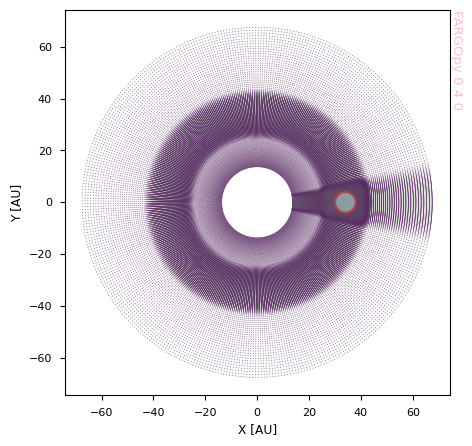

(<Figure size 700x500 with 1 Axes>, <Axes: xlabel='X [AU]', ylabel='Y [AU]'>)

In [2]:
PATH = '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'  # <-- pon tu ruta
SNAP = 200


sim = fp.Simulation(output_dir=PATH)
sim.units('CGS')
sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

sim.plot_mesh(snapshot=0, slice='theta=1.567', planet=0, draw_hill=True, hill_frac=1.0,
                  figsize=(7,5), point_size=1, line_alpha=0.1, cmap='viridis', show=True)


#  Load midplane slice and build uniform grid

Load gas density and velocity on a midplane slice and create a uniform grid for plotting.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


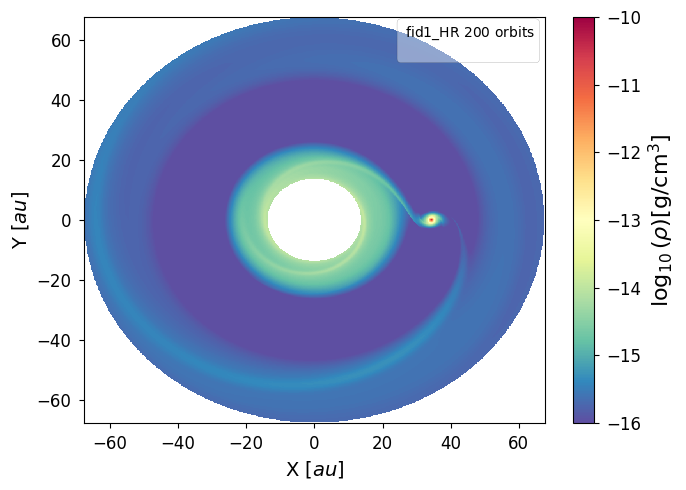

In [3]:

# =========================
# Settings
# =========================

SLICE = 'theta=1.569'

sim = fp.Simulation(output_dir=PATH)
sim.units('CGS')
sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

# -------------------------
# Load midplane slice
# -------------------------


data = sim.load_field(
    fields=['gasdens', 'gasv'],
    snapshot = SNAP,
    slice = SLICE,
    interpolate=True
)

# -------------------------
# Uniform grid
# -------------------------
res = 720
xmin, xmax = data.var1_mesh[0].min(), data.var1_mesh[0].max()
ymin, ymax = data.var2_mesh[0].min(), data.var2_mesh[0].max()

xs = np.linspace(xmin, xmax, res)
ys = np.linspace(ymin, ymax, res)
X, Y = np.meshgrid(xs, ys)

# -------------------------
# Evaluate fields
# -------------------------
rho = data.evaluate(field='gasdens', time = SNAP, var1=X, var2=Y)

plt.close('all')
fig, ax = plt.subplots(figsize=(7, 5))

# Background density (optional)
vmin, vmax = -16, -10
norm= colors.Normalize(vmin=vmin, vmax=vmax)
pcm = ax.pcolormesh(X*sim.UL/ sim.AU, Y*sim.UL/ sim.AU, np.log10(rho*sim.URHO), norm=norm, cmap='Spectral_r', shading='auto')


cbar = fig.colorbar(pcm, ax=ax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(r'$\log_{10}(\rho) [\mathrm{g/cm}^3]$', fontsize=16)


ax.set_xlabel(r'X $[au]$', fontsize=14)
ax.set_ylabel(r'Y $[au]$', fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(False)


# Optional limits in R_H
# ax.set_xlim(-1.2, 1.2)
# ax.set_ylim(-1.2, 1.2)

# ax.legend(fontsize=12)
plt.tight_layout()

# =========================
# Text box (upper-right)
# =========================
textstr = (
    rf" fid1_HR$~{SNAP}\ \mathrm{{orbits}}$" "\n"
)

ax.text(
    0.98, 0.98, textstr,
    transform=ax.transAxes,          # coordinates in axis space
    fontsize=10,
    va='top', ha='right',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='black',
        alpha=0.4
    )
)
#plt.savefig('media/densxy_fid3hr.png', dpi=300)
plt.show()


#  Zoom into planetary surroundings

Prepare a high-resolution cut around the planet and plot local density in Hill radii.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


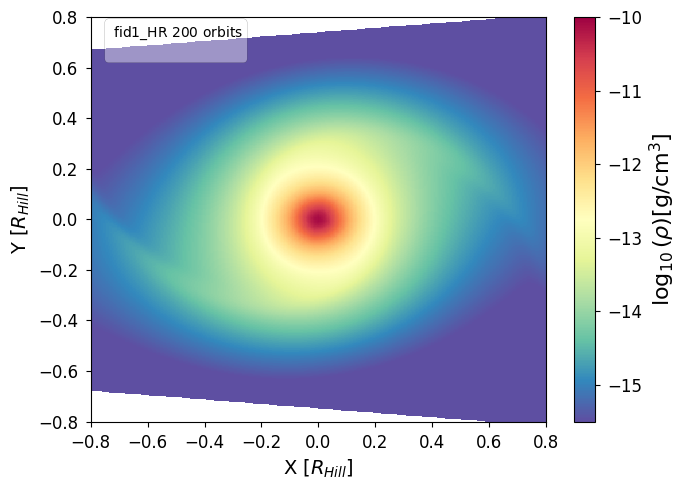

In [4]:

# =========================
# Settings
# =========================

SNAP = 200

sim = fp.Simulation(output_dir=PATH)
sim.units('CGS')
sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

# -------------------------
# Load midplane slice
# -------------------------

SLICE = 'theta=1.569, r=[0.8,1.2], phi=[-5 deg, 5 deg]'

data = sim.load_field(
    fields=['gasdens', 'gasv'],
    snapshot = SNAP,
    slice = SLICE,
    interpolate=True
)

# -------------------------
# Uniform grid
# -------------------------
res = 720
xmin, xmax = data.var1_mesh[0].min(), data.var1_mesh[0].max()
ymin, ymax = data.var2_mesh[0].min(), data.var2_mesh[0].max()

xs = np.linspace(xmin, xmax, res)
ys = np.linspace(ymin, ymax, res)
X, Y = np.meshgrid(xs, ys)

# -------------------------
# Evaluate fields
# -------------------------
rho = data.evaluate(field='gasdens', time = SNAP, var1=X, var2=Y)

plt.close('all')

pds70c = sim.load_planets(snapshot = SNAP)[0]
xp, yp = pds70c.pos.x, pds70c.pos.y
RH = pds70c.hill_radius

# Planet-centered coords in R_H
Xr = (X - xp) / RH
Yr = (Y - yp) / RH


fig, ax = plt.subplots(figsize=(7, 5))

# Background density (optional)
vmin, vmax = -15.5, -10
norm= colors.Normalize(vmin=vmin, vmax=vmax)
pcm = ax.pcolormesh(Xr, Yr, np.log10(rho*sim.URHO), norm=norm, cmap='Spectral_r', shading='auto')


cbar = fig.colorbar(pcm, ax=ax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(r'$\log_{10}(\rho) [\mathrm{g/cm}^3]$', fontsize=16)




ax.set_xlabel(r'X [$R_{Hill}$]', fontsize=14)
ax.set_ylabel(r'Y [$R_{Hill}$]', fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(False)


# Optional limits in R_H
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.8, 0.8)

# ax.legend(fontsize=12)
plt.tight_layout()

# =========================
# Text box (upper-right)
# =========================
textstr = (
    rf" fid1_HR$~{SNAP}\ \mathrm{{orbits}}$" "\n"
)

ax.text(
    0.04, 0.98, textstr,
    transform=ax.transAxes,          # coordinates in axis space
    fontsize=10,
    va='top', ha='left',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='black',
        alpha=0.4
    )
)
#plt.savefig('media/densxy_fid3hr.png', dpi=300)
plt.show()

#  Compare orbital-plane density across runs

Evaluate log-density on a shared grid for multiple simulations and compare panels.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.


Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.
Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/ou

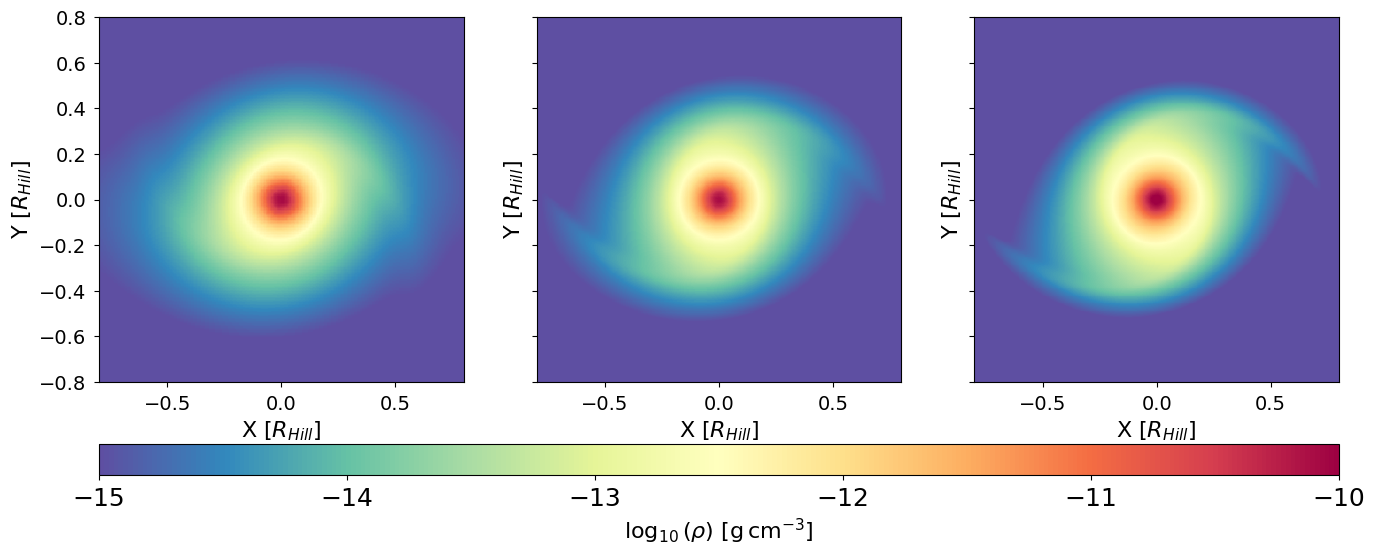

In [ ]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Settings

SLICE = 'theta=1.569, r=[0.8,1.2], phi=[-10 deg, 10 deg]'
RES = 720  # grid resolution
VMIN, VMAX = -15, -10.0  # shared color limits (log10 rho)

paths = [
    ('fid1', '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'),
    ('fid2', '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'),
    ('fid3', '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs'),
]

# Prepare grid from first simulation
name0, path0 = paths[0]
sim0 = fp.Simulation(output_dir=path0)
sim0.units('CGS')
sim0.set_units(UL=34*sim0.AU, UM=0.76*sim0.MSUN)
data0 = sim0.load_field(fields=['gasdens'], snapshot=SNAP, slice=SLICE, interpolate=True)
xmin, xmax = data0.var1_mesh[0].min(), data0.var1_mesh[0].max()
ymin, ymax = data0.var2_mesh[0].min(), data0.var2_mesh[0].max()
xs = np.linspace(xmin, xmax, RES)
ys = np.linspace(ymin, ymax, RES)
X, Y = np.meshgrid(xs, ys)

# Evaluate log10(rho) for each run (same grid), store planet centering info
logrho_list = []
centers = []
RHs = []
sims = []
for label, path in paths:
    sim = fp.Simulation(output_dir=path)
    sim.units('CGS')
    sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)
    data = sim.load_field(fields=['gasdens'], snapshot=SNAP, slice=SLICE, interpolate=True)
    rho = data.evaluate(field='gasdens', time=SNAP, var1=X, var2=Y)
    logrho = np.log10(rho * sim.URHO)
    logrho_list.append(logrho)
    p = sim.load_planets(snapshot=SNAP)[0]
    centers.append((p.pos.x, p.pos.y))
    RHs.append(p.hill_radius)
    sims.append(sim)

# Shared normalization
norm = colors.Normalize(vmin=VMIN, vmax=VMAX)

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(16, 8), sharex=True, sharey=True)

for ax, (label, _), logrho, (xp, yp), RH, sim in zip(axs, paths, logrho_list, centers, RHs, sims):
    Xr = (X - xp) / RH
    Yr = (Y - yp) / RH
    pcm = ax.pcolormesh(Xr, Yr, logrho, norm=norm, cmap='Spectral_r', shading='auto')
    #ax.set_title(label, fontsize=16, pad=6)
    ax.set_xlabel('X [$R_{Hill}$]', fontsize=16)
    ax.set_ylabel('Y [$R_{Hill}$]', fontsize=16)
    ax.set_aspect('equal')
    ax.set_xlim(-0.8, 0.8)
    ax.set_ylim(-0.8, 0.8)
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=14)


# Reserve space below axes and create dedicated colorbar axis to avoid overlap
cbar = fig.colorbar(
    pcm,
    ax=axs,                    # KEY: share with all axes
    orientation="horizontal",
    location="bottom",
    pad=0.10,                  # separation relative to the plots
    fraction=0.06,             # relative thickness
    aspect=40                  # shape/style
)
cbar.set_label(r'$\\log_{10}(\\rho)\\ \\mathrm{[g\\,cm^{-3}]}$', fontsize=16)
cbar.ax.tick_params(labelsize=18)

# Improve overall layout and readability
for ax in axs:
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    ax.tick_params(labelsize=14)

#plt.tight_layout()
plt.show()


#  Streamlines (XY) zoomed to planet environment

Compute velocities and $v_{\phi}/V_{k}$ then plot streamlines over density background near the planet.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.


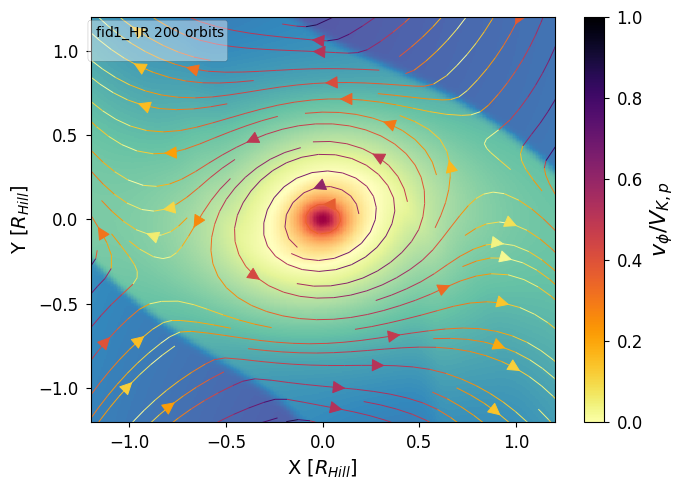

In [ ]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.style.use('seaborn-v0_8-paper')
import matplotlib.colors as colors
from matplotlib.cm import ScalarMappable
# =========================
# Settings
# =========================
PATH = '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'  # <-- set your path here
SNAP = 200

sim = fp.Simulation(output_dir=PATH)
sim.units('CGS')
sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

# -------------------------
# Load midplane slice
# -------------------------

SLICE = 'theta=1.569,r=[0.8,1.3],phi=[-10 deg,10 deg]'

data = sim.load_field(
    fields=['gasdens', 'gasv'],
    snapshot = SNAP,
    slice = SLICE,
    interpolate=True,
)

# -------------------------
# Uniform grid
# -------------------------
res = 720
xmin, xmax = data.var1_mesh[0].min(), data.var1_mesh[0].max()
ymin, ymax = data.var2_mesh[0].min(), data.var2_mesh[0].max()

xs = np.linspace(xmin, xmax, res)
ys = np.linspace(ymin, ymax, res)
X, Y = np.meshgrid(xs, ys)

# -------------------------
# Evaluate fields
# -------------------------
vel = data.evaluate(field='gasv', time = SNAP, var1=X, var2=Y)
rho = data.evaluate(field='gasdens', time = SNAP, var1=X, var2=Y)

# Convert velocity to km/s
vx = vel[0, :] * (sim.UL/sim.UT) * 1e-5
vy = vel[1, :] * (sim.UL/sim.UT) * 1e-5

# -------------------------
# Planet center and Hill radius
# -------------------------
pds70c = sim.load_planets(snapshot = SNAP)[0]
xp, yp = pds70c.pos.x, pds70c.pos.y
RH = pds70c.hill_radius

# Planet-centered coords in R_H
Xr = (X - xp) / RH
Yr = (Y - yp) / RH

# -------------------------
# Compute vphi/Vk,p (around the planet)
# -------------------------
G_cgs = 6.67430e-8
Mp_cgs = pds70c.mass * sim.UM

dx = X - xp
dy = Y - yp
r = np.sqrt(dx**2 + dy**2)

phi = np.arctan2(dy, dx)
ephix = -np.sin(phi)
ephiy =  np.cos(phi)

vphi = vx*ephix + vy*ephiy  # km/s

r_cgs = r * sim.UL
Vk = np.sqrt(G_cgs * Mp_cgs / np.where(r_cgs > 0, r_cgs, np.nan)) * 1e-5  # km/s

q = vphi / Vk  # vphi/Vk,p

# mask tiny radii to avoid divergence/noise
q = np.where((r/RH) < 0.03, np.nan, q)

# -------------------------
# Plot: density background + streamlines colored by vphi/Vk,p
# -------------------------
plt.close('all')
fig, ax = plt.subplots(figsize=(7, 5))

# Background density (optional)
pcm = ax.pcolormesh(Xr, Yr, np.log10(rho), cmap='Spectral_r', shading='auto')
vmin, vmax = 0.0, 1.0
norm = colors.Normalize(vmin=vmin, vmax=vmax)
# Streamlines in planet-centered coordinates
strm = ax.streamplot(
    Xr, Yr, vx, vy,
    linewidth=0.7, density=2, arrowsize=2,
    color=np.abs(q),
    cmap='inferno_r',
    norm=norm
)


# Optional circle at 0.3 R_H
circle = patches.Circle(
    (0.0, 0.0), 0.3, edgecolor='white', facecolor='none',
    linewidth=1.5, linestyle='--', label=r'0.3 $R_{Hill}$'
)
# ax.add_patch(circle)


sm = ScalarMappable(norm=norm, cmap='inferno_r')
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(r'$v_\phi/V_{K,p}$', fontsize=16)


ax.set_xlabel(r'X [$R_{Hill}$]', fontsize=14)
ax.set_ylabel(r'Y [$R_{Hill}$]', fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(False)


# Optional limits in R_H
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

# ax.legend(fontsize=12)
plt.tight_layout()

# =========================
# Text box (upper-right)
# =========================
textstr = (
    rf" fid1_HR$~{SNAP}\\ \mathrm{{orbits}}$" "\n"
)

ax.text(
    0.0, 0.98, textstr,
    transform=ax.transAxes,          # coordinates in axis space
    fontsize=10,
    va='top', ha='left',
    bbox=dict(
        boxstyle='round,pad=0.2',
        facecolor='white',
        edgecolor='black',
        alpha=0.4
    )
)
#plt.savefig('media/strmxy_fid1hr.png', dpi=300)
plt.show()


#  Multi-run streamline comparison (XY)

Build a shared grid and plot streamlines for three simulations with a shared colorbar.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.


Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.
Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/ou

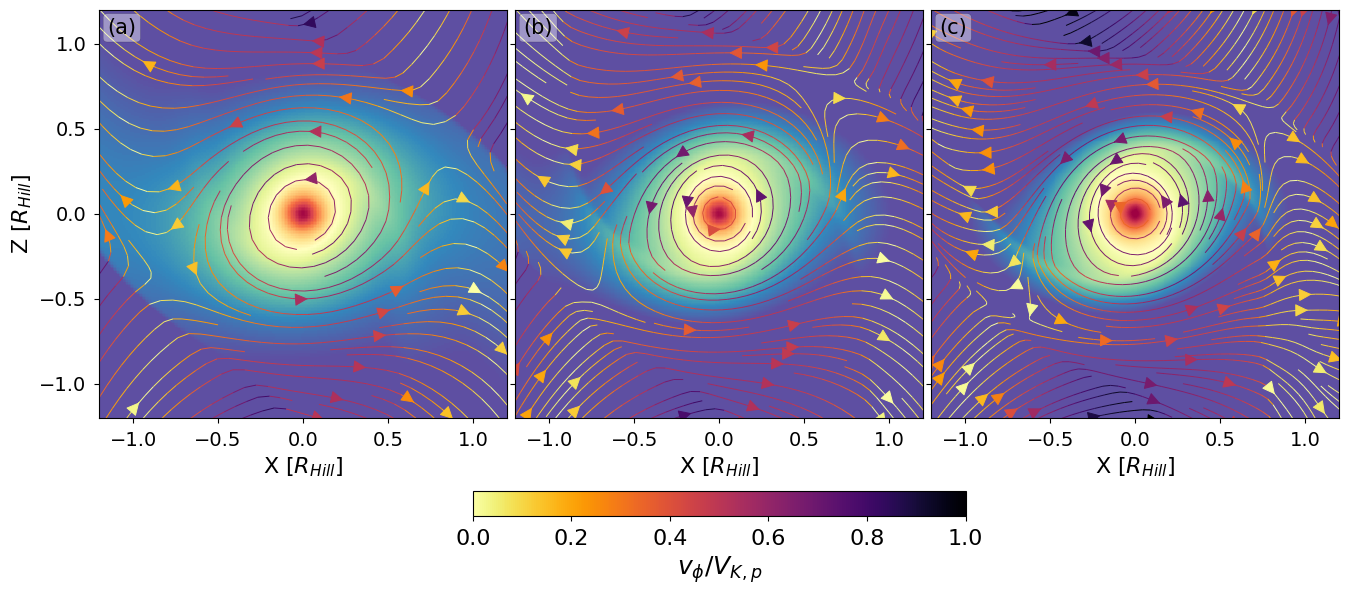

In [ ]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
from matplotlib.cm import ScalarMappable

plt.style.use('seaborn-v0_8-paper')

# =========================
# Settings
# =========================
SNAP  = 200
SLICE = 'theta=1.569,r=[0.7,1.3],phi=[-14 deg,14 deg]'
RES   = 720

# Background density limits (log10 rho in CGS)
RHO_VMIN, RHO_VMAX = -15.6, -10.0

# Streamline colorbar limits (vphi/Vk,p)
Q_VMIN, Q_VMAX = 0.0, 1.0

paths = [
    ('fid1', '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'),
    ('fid2', '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'),
    ('fid3', '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs'),
]

# =========================
# Build shared grid from first simulation
# =========================
name0, path0 = paths[0]
sim0 = fp.Simulation(output_dir=path0)
sim0.units('CGS')
sim0.set_units(UL=34*sim0.AU, UM=0.76*sim0.MSUN)

data0 = sim0.load_field(fields=['gasdens', 'gasv'], snapshot=SNAP, slice=SLICE, interpolate=True)
xmin, xmax = data0.var1_mesh[0].min(), data0.var1_mesh[0].max()
ymin, ymax = data0.var2_mesh[0].min(), data0.var2_mesh[0].max()

xs = np.linspace(xmin, xmax, RES)
ys = np.linspace(ymin, ymax, RES)
X, Y = np.meshgrid(xs, ys)

# =========================
# Norms (fixed)
# =========================
rho_norm = colors.Normalize(vmin=RHO_VMIN, vmax=RHO_VMAX)
q_norm   = colors.Normalize(vmin=Q_VMIN,   vmax=Q_VMAX)

# ScalarMappable ONLY for the streamline colorbar
sm = ScalarMappable(norm=q_norm, cmap='inferno_r')
sm.set_array([])

# =========================
# Plotting: 3 subplots (like your reference code)
# =========================
fig, axs = plt.subplots(1, 3, figsize=(16, 8), sharex=True, sharey=True, gridspec_kw={'wspace': 0.02})


last_pcm = None  # (not used for colorbar; kept just in case)
panel=['(a)', '(b)', '(c)']
axs[0].set_ylabel(r'Y [$R_{Hill}$]', fontsize=16)

for i, (ax, (label, path)) in enumerate(zip(axs, paths)):
    sim = fp.Simulation(output_dir=path)
    sim.units('CGS')
    sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

    data = sim.load_field(fields=['gasdens', 'gasv'], snapshot=SNAP, slice=SLICE, interpolate=True)

    # evaluate fields on shared grid
    vel = data.evaluate(field='gasv', time=SNAP, var1=X, var2=Y)
    rho = data.evaluate(field='gasdens', time=SNAP, var1=X, var2=Y)

    # velocity to km/s
    vx = vel[0, :] * (sim.UL/sim.UT) * 1e-5
    vy = vel[1, :] * (sim.UL/sim.UT) * 1e-5

    # planet + Hill
    p = sim.load_planets(snapshot=SNAP)[0]
    xp, yp = p.pos.x, p.pos.y
    RH = p.hill_radius

    # planet-centered coords in R_H
    Xr = (X - xp) / RH
    Yr = (Y - yp) / RH

    # --- vphi/Vk,p around the planet ---
    G_cgs  = 6.67430e-8
    Mp_cgs = p.mass * sim.UM

    dx = X - xp
    dy = Y - yp
    r  = np.sqrt(dx**2 + dy**2)

    phi   = np.arctan2(dy, dx)
    ephix = -np.sin(phi)
    ephiy =  np.cos(phi)

    vphi = vx*ephix + vy*ephiy  # km/s

    r_cgs = r * sim.UL
    Vk = np.sqrt(G_cgs * Mp_cgs / np.where(r_cgs > 0, r_cgs, np.nan)) * 1e-5  # km/s

    q = vphi / Vk
    q = np.where((r/RH) < 0.03, np.nan, q)  # mask tiny radii
    qabs = np.abs(q)

    # =========================
    # Plot: density background (fixed vmin/vmax) + streamlines (colored)
    # =========================
    logrho = np.log10(rho * sim.URHO)  # CGS
    last_pcm = ax.pcolormesh(Xr, Yr, logrho, cmap='Spectral_r', norm=rho_norm, shading='auto')

    ax.streamplot(
        Xr, Yr, vx, vy,
        linewidth=0.7, density=3, arrowsize=2,
        color=qabs,
        cmap='inferno_r',
        norm=q_norm
    )

    # labels / formatting
    
    ax.set_xlabel(r'X [$R_{Hill}$]', fontsize=16)
    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # textbox
    ax.text(
        0.02, 0.98,
        panel[i],
        transform=ax.transAxes,
        fontsize=15,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='black', alpha=0.4)
    )


# =========================
# Shared colorbar (BOTTOM) for STREAMLINES (like your reference)
# =========================
cbar = fig.colorbar(
    sm,
    ax=axs,
    orientation="horizontal",
    location="bottom",
    pad=0.12,
    fraction=0.04,
    aspect=20
)
cbar.set_label(r'$v_\phi/V_{K,p}$', fontsize=18)
cbar.ax.tick_params(labelsize=16)

# overall cosmetics
for ax in axs:
    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    ax.tick_params(labelsize=14)

plt.show()


#  Streamlines in XZ (vertical) plane

Load vertical slice data and plot streamlines colored by velocity magnitude.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.


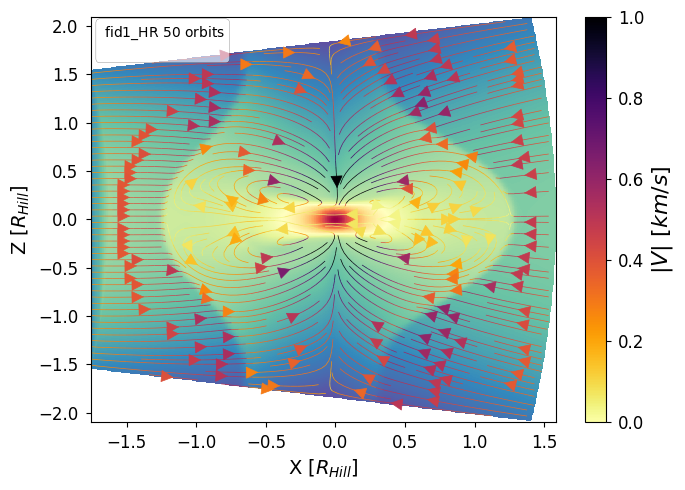

In [ ]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.style.use('seaborn-v0_8-paper')
import matplotlib.colors as colors
from matplotlib.cm import ScalarMappable

# =========================
# Settings
# =========================
PATH = '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'  # <-- set your path here
SNAP = 50

sim = fp.Simulation(output_dir=PATH)
sim.units('CGS')
sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

# -------------------------
# Load midplane slice
# -------------------------

SLICE = 'phi=0,r=[0.85,1.15]'

data = sim.load_field(
    fields=['gasdens', 'gasv'],
    snapshot = SNAP,
    slice=SLICE,
    interpolate=True,
)

# -------------------------
# Uniform grid
# -------------------------
res = 720
xmin, xmax = data.var1_mesh[0].min(), data.var1_mesh[0].max()
zmin, zmax = data.var3_mesh[0].min(), data.var3_mesh[0].max()

xs = np.linspace(xmin, xmax, res)
zs = np.linspace(-zmax, zmax, res)
X, Z = np.meshgrid(xs, zs)

# -------------------------
# Evaluate fields
# -------------------------
vel = data.evaluate(field='gasv', time = SNAP, var1=X, var3=Z,reflect=True)
rho = data.evaluate(field='gasdens', time = SNAP, var1=X, var3=Z,reflect=True)
# Convert velocity to km/s
vx = vel[0, :] * (sim.UL/sim.UT) * 1e-5
vz = vel[2, :] * (sim.UL/sim.UT) * 1e-5
vmag = np.sqrt(vx**2 + vz**2)

# -------------------------
# Planet center and Hill radius
# -------------------------
pds70c = sim.load_planets(snapshot = SNAP)[0]
xp, zp = pds70c.pos.x, pds70c.pos.z
RH = pds70c.hill_radius

# Planet-centered coords in R_H
Xr = (X - xp) / RH
Zr = (Z - zp) / RH

# -------------------------
# Plot: density background + streamlines colored by velocities
# -------------------------
plt.close('all')
fig, ax = plt.subplots(figsize=(7, 5))

# Background density (optional)
pcm = ax.pcolormesh(Xr, Zr, np.log10(rho), cmap='Spectral_r', shading='auto')
vmin, vmax = 0.0, 1
norm = colors.Normalize(vmin=vmin, vmax=vmax)
# Streamlines in planet-centered coordinates
strm = ax.streamplot(
    Xr, Zr, vx, vz,              # NOTE: streamplot uses coords (Xr,Zr) but vectors (vx,vz)
    linewidth=0.5, density=2.2, arrowsize=2,
    color=vmag, cmap='inferno_r',norm=norm,
)

# Optional circle at 0.3 R_H
circle = patches.Circle(
    (0.0, 0.0), 0.3, edgecolor='white', facecolor='none',
    linewidth=1.5, linestyle='--', label=r'0.3 $R_{Hill}$'
)
# ax.add_patch(circle)

cbar = fig.colorbar(strm.lines, ax=ax)
cbar.ax.tick_params(labelsize=12)
cbar.set_label(r'$|V|~ [km/s]$', fontsize=16)
#sm = ScalarMappable(norm=norm, cmap='Spectral')


ax.set_xlabel(r'X [$R_{Hill}$]', fontsize=14)
ax.set_ylabel(r'Z [$R_{Hill}$]', fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(False)


# Optional limits in R_H
# ax.set_xlim(-1.2, 1.2)
# ax.set_ylim(-1.2, 1.2)

# ax.legend(fontsize=12)
plt.tight_layout()

# =========================
# Text box (upper-right)
# =========================
textstr = (
    rf" fid1_HR$~{SNAP}\\ \mathrm{{orbits}}$" "\n"
)

ax.text(
    0.02, 0.98, textstr,
    transform=ax.transAxes,          # coordinates in axis space
    fontsize=10,
    va='top', ha='left',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='black',
        alpha=0.6
    )
)
#plt.savefig('media/strmxz_fid1hr.png', dpi=300)
plt.show()


#  Compare XZ streamlines across runs

Evaluate vertical streamlines for multiple runs on a shared grid and compare panels.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.


Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.
Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/ou

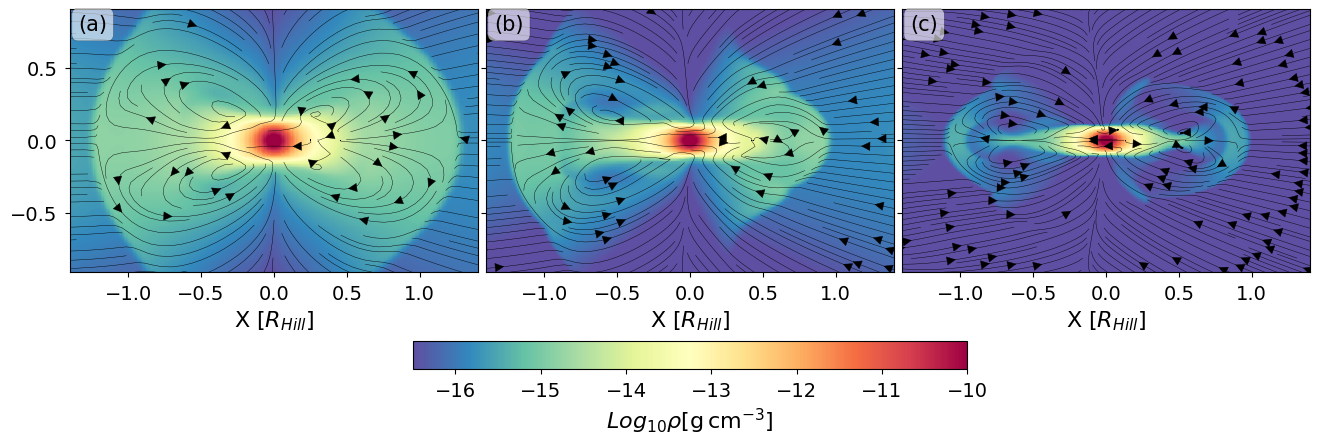

In [ ]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
from matplotlib.cm import ScalarMappable

plt.style.use('seaborn-v0_8-paper')

# =========================
# Settings
# =========================
SNAP  = 50
SLICE = 'phi=0,r=[0.7,1.3]'
RES   = 720

# Background density limits (log10 rho, CGS)
RHO_VMIN, RHO_VMAX = -16.5, -10.0

# Streamline colorbar limits (|V| in km/s)
V_VMIN, V_VMAX = 0.0, 2.0

paths = [
    ('fid1', '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'),
    ('fid2', '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'),
    ('fid3', '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs'),
]

# =========================
# Build shared grid from first simulation
# =========================
label0, path0 = paths[0]
sim0 = fp.Simulation(output_dir=path0)
sim0.units('CGS')
sim0.set_units(UL=34*sim0.AU, UM=0.76*sim0.MSUN)

data0 = sim0.load_field(
    fields=['gasdens', 'gasv'],
    snapshot=SNAP,
    slice=SLICE,
    interpolate=True,
)

xmin, xmax = data0.var1_mesh[0].min(), data0.var1_mesh[0].max()
zmin, zmax = data0.var3_mesh[0].min(), data0.var3_mesh[0].max()

xs = np.linspace(xmin, xmax, RES)
zs = np.linspace(-zmax, zmax, RES)
X, Z = np.meshgrid(xs, zs)

# =========================
# Normalizations
# =========================
rho_norm = colors.Normalize(vmin=RHO_VMIN, vmax=RHO_VMAX)
v_norm   = colors.Normalize(vmin=V_VMIN,   vmax=V_VMAX)

# ScalarMappable ONLY for streamline colorbar
sm = ScalarMappable(norm=rho_norm, cmap='Spectral_r')
sm.set_array([])

# =========================
# Plotting
# =========================
fig, axs = plt.subplots(
    1, 3,
    figsize=(16, 6),
    sharex=True,
    sharey=True
)
panel = ['(a)', '(b)', '(c)']

# Explicit control of horizontal spacing
fig.subplots_adjust(
    wspace=0.02  # KEY ADJUSTMENT
)
ax.set_ylabel(r'Z [$R_{Hill}$]', fontsize=16)
for i, (ax, (label, path)) in enumerate(zip(axs, paths)):
    sim = fp.Simulation(output_dir=path)
    sim.units('CGS')
    sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

    data = sim.load_field(
        fields=['gasdens', 'gasv'],
        snapshot=SNAP,
        slice=SLICE,
        interpolate=True
    )

    # Evaluate fields
    vel = data.evaluate(field='gasv', time=SNAP, var1=X, var3=Z, reflect=True)
    rho = data.evaluate(field='gasdens', time=SNAP, var1=X, var3=Z, reflect=True)

    # velocities in km/s
    vx = vel[0, :] * (sim.UL/sim.UT) * 1e-5
    vz = vel[2, :] * (sim.UL/sim.UT) * 1e-5
    vmag = np.sqrt(vx**2 + vz**2)

    # planet + Hill
    p = sim.load_planets(snapshot=SNAP)[0]
    xp, zp = p.pos.x, p.pos.z
    RH = p.hill_radius

    # planet-centered coords
    Xr = (X - xp) / RH
    Zr = (Z - zp) / RH

    # Background density (fixed limits, no colorbar)
    logrho = np.log10(rho * sim.URHO)
    ax.pcolormesh(
        Xr, Zr, logrho,
        cmap='Spectral_r',
        norm=rho_norm,
        shading='auto'
    )

    # Streamlines colored by |V|
    ax.streamplot(
        Xr, Zr, vx, vz,
        linewidth=0.3,
        density=3.0,
        arrowsize=1.5,
        color='black'
    )



    ax.set_xlabel(r'X [$R_{Hill}$]', fontsize=16)
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-0.9, 0.9)
    ax.tick_params(labelsize=14)
    ax.grid(False)
    ax.set_aspect('equal')

    ax.text(
        0.02, 0.98,
        panel[i],
        transform=ax.transAxes,
        fontsize=15,
        va='top', ha='left',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='black',
            alpha=0.6
        )
    )

# =========================
# Shared colorbar (BOTTOM) – STREAMLINES
# =========================
cbar = fig.colorbar(
    sm,
    ax=axs,
    orientation='horizontal',
    location='bottom',
    pad=0.15,
    fraction=0.06,
    aspect=20,
)


cbar.set_label(r'$Log_{10}\\rho \\mathrm{[g\\,cm^{-3}]}$', fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.show()


#  Rotation map with streamlines

Compute $v_{\phi}/V_{k}$ around the planet and overlay streamlines on the rotation map.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


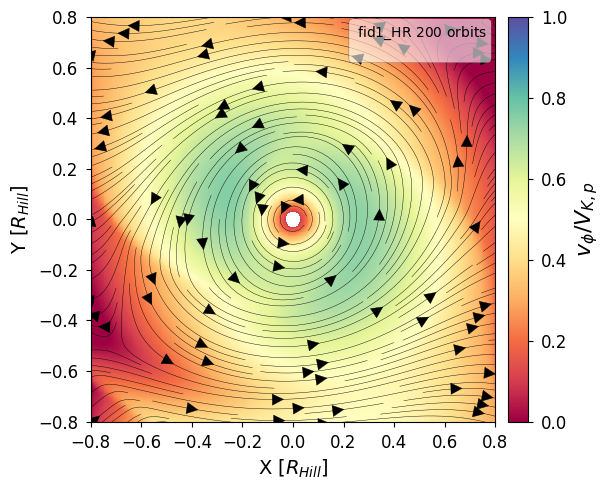

In [9]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
from matplotlib.cm import ScalarMappable

plt.style.use("seaborn-v0_8-paper")

# =========================
# Settings
# =========================

SNAP = 200
RES  = 720

# -------------------------
# Simulation
# -------------------------
sim = fp.Simulation(output_dir=PATH)
sim.units("CGS")
sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

# -------------------------
# Load midplane XY slice (planet vicinity)
# -------------------------
SLICE_XY = "theta=1.569,r=[0.85,1.15],phi=[-7 deg,7 deg]"
data = sim.load_field(
    fields=["gasdens", "gasv"],
    snapshot = SNAP,
    slice=SLICE_XY,
    interpolate=True
)

# -------------------------
# Uniform grid (XY)
# -------------------------
xmin, xmax = data.var1_mesh[0].min(), data.var1_mesh[0].max()
ymin, ymax = data.var2_mesh[0].min(), data.var2_mesh[0].max()

xs = np.linspace(xmin, xmax, RES)
ys = np.linspace(ymin, ymax, RES)
X, Y = np.meshgrid(xs, ys)

# -------------------------
# Evaluate fields
# -------------------------
vel = data.evaluate(field="gasv", time = SNAP, var1=X, var2=Y)

# velocities in km/s (physical)
vx = vel[0, :] * (sim.UL/sim.UT) * 1e-5
vy = vel[1, :] * (sim.UL/sim.UT) * 1e-5

# -------------------------
# Planet center and Hill radius
# -------------------------
p = sim.load_planets(snapshot = SNAP)[0]
xp, yp = p.pos.x, p.pos.y
RH = p.hill_radius

# planet-centered coords in R_H
Xr = (X - xp) / RH
Yr = (Y - yp) / RH

# -------------------------
# Map: vphi / Vk,p  (around the planet)
# -------------------------
G_cgs  = 6.67430e-8
Mp_cgs = p.mass * sim.UM

dx = X - xp
dy = Y - yp
r  = np.sqrt(dx**2 + dy**2)

phi = np.arctan2(dy, dx)
ephix = -np.sin(phi)
ephiy =  np.cos(phi)

vphi = vx*ephix + vy*ephiy                    # km/s
r_cgs = r * sim.UL                             # cm
Vk    = np.sqrt(G_cgs*Mp_cgs/np.where(r_cgs > 0, r_cgs, np.nan)) * 1e-5  # km/s

q = vphi / Vk                                  # dimensionless

# avoid garbage at tiny radii
q = np.where((r/RH) < 0.03, np.nan, q)

# -------------------------
# Plot: keplerian-rotation map background + streamlines on top
# -------------------------
plt.close("all")
fig, ax = plt.subplots(figsize=(7, 5))

# Background: map of "zones of Keplerian rotation" (use q directly)
# If you prefer "how close to Keplerian" use np.abs(1 - q) instead.
q_vmin, q_vmax = 0.0, 1.0
q_norm = colors.Normalize(vmin=q_vmin, vmax=q_vmax)

pcm = ax.pcolormesh(
    Xr, Yr, q,
    shading="auto",
    cmap="Spectral",
    norm=q_norm
)

# Streamlines: drawn over q-map, colored by |q| (or any scalar you want)
strm_norm = colors.Normalize(vmin=0.0, vmax=1)
strm = ax.streamplot(
    Xr, Yr, vx, vy,
    linewidth=0.3, density=3, arrowsize=2,
    color='black',
    norm=strm_norm
)

# Optional circle (0.3 R_H)
# ax.add_patch(patches.Circle((0.0, 0.0), 0.3, edgecolor="white",
#                             facecolor="none", linewidth=1.5, linestyle="--"))

# Colorbar for background (q-map)
cbar_bg = fig.colorbar(pcm, ax=ax, pad=0.02)
cbar_bg.ax.tick_params(labelsize=12)
cbar_bg.set_label(r"$v_\phi/V_{K,p}$", fontsize=16)

# (Optional) second colorbar for streamline color (if you want it separate)
# sm = ScalarMappable(norm=strm_norm, cmap="inferno_r")
# sm.set_array([])
# cbar_sl = fig.colorbar(sm, ax=ax, pad=0.10)
# cbar_sl.ax.tick_params(labelsize=12)
# cbar_sl.set_label(r"$|v_\phi/V_{K,p}|$", fontsize=16)

ax.set_xlabel(r"X [$R_{Hill}$]", fontsize=14)
ax.set_ylabel(r"Y [$R_{Hill}$]", fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(False)
ax.set_aspect('equal')
ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.8, 0.8)

plt.tight_layout()


# Text box
textstr = rf" fid1_HR$~{SNAP}\ \mathrm{{orbits}}$" "\n"
ax.text(
    0.98, 0.98, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.6)
)

# plt.savefig("media/kepler_map_streamlines_xy_fid1hr.png", dpi=300)
plt.show()

#  Single rotation map and radial profile

Create a 2D map of $v_{\phi}/V_{k}$ and compute radial profiles with uncertainties.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


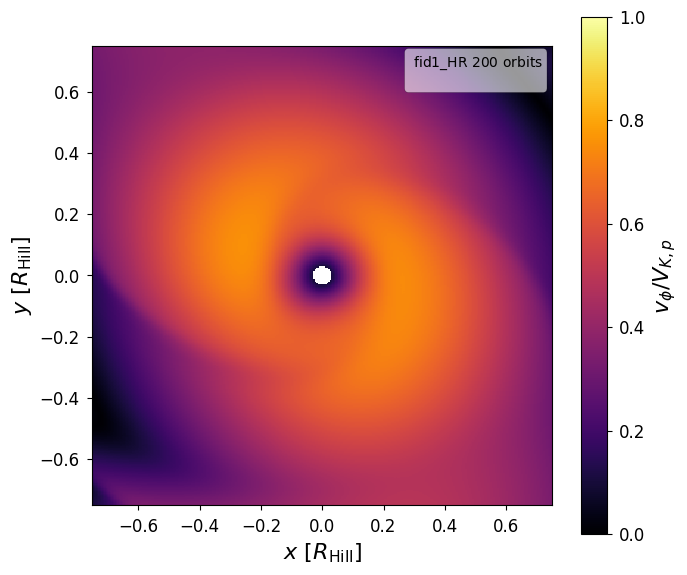

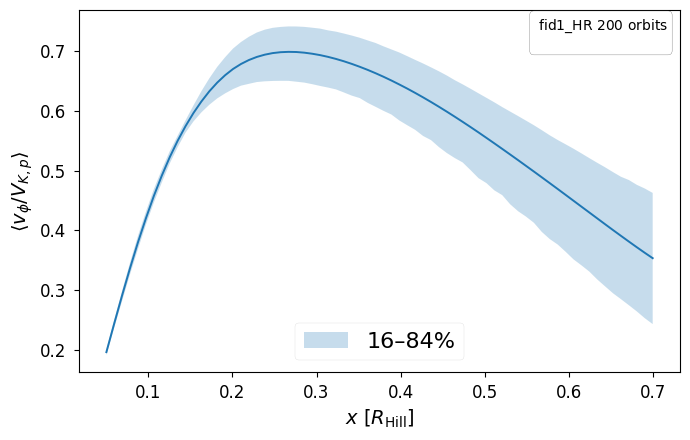

In [10]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-paper')

# =========================
# User settings
# =========================
SNAP = 200

# Midplane slice (adjust theta if needed)
SLICE_XY = 'theta=1.569,r=[0.8,1.2],phi=[-8.5 deg,8.5 deg]'

# Grid resolution for the 2D map
RES2D = 720

# Radial profile settings (in units of Hill radius)
RMIN_RH = 0.05
RMAX_RH = 0.70
NR = 70
NPHI = 96

# =========================
# Load simulation and planet
# =========================
sim = fp.Simulation(output_dir=PATH)
sim.units('CGS')
sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

p = sim.load_planets(snapshot = SNAP)[0]
xp, yp = p.pos.x, p.pos.y
RH = p.hill_radius

G = 6.67430e-8
Mp_cgs = p.mass * sim.UM

# =========================
# Load fields (midplane slice)
# =========================
data = sim.load_field(fields=['gasdens', 'gasv'],
                      snapshot = SNAP,
                      slice=SLICE_XY,
                      interpolate=True)

# =========================
# Build uniform grid for 2D map
# =========================
xmin, xmax = data.var1_mesh[0].min(), data.var1_mesh[0].max()
ymin, ymax = data.var2_mesh[0].min(), data.var2_mesh[0].max()

xs = np.linspace(xmin, xmax, RES2D)
ys = np.linspace(ymin, ymax, RES2D)
X, Y = np.meshgrid(xs, ys)

# Evaluate fields
vel = data.evaluate(field='gasv', time = SNAP, var1=X, var2=Y)
rho = data.evaluate(field='gasdens', time = SNAP, var1=X, var2=Y)

# Velocities in cgs
vx = vel[0, :] * (sim.UL/sim.UT)   # cm/s
vy = vel[1, :] * (sim.UL/sim.UT)   # cm/s

# Planet-centered coordinates
dx = X - xp
dy = Y - yp
r = np.sqrt(dx**2 + dy**2)

# e_phi around planet (avoid r=0)
phi = np.arctan2(dy, dx)
ephix = -np.sin(phi)
ephiy =  np.cos(phi)

# v_phi around planet
vphi = vx*ephix + vy*ephiy

# Keplerian speed around planet
r_cgs = r * sim.UL
Vk = np.sqrt(G * Mp_cgs / np.where(r_cgs > 0, r_cgs, np.nan))

vphi_over_Vk = vphi / Vk

# Mask a small central region to avoid divergence at r->0
mask_core = (r / RH) < 0.03
vphi_over_Vk = np.where(mask_core, np.nan, vphi_over_Vk)

# =========================
# 2D MAP: vphi/Vk,p
# =========================
Xr = dx / RH
Yr = dy / RH

plt.close('all')
fig1, ax1 = plt.subplots(figsize=(7, 6))

pcm = ax1.pcolormesh(Xr, Yr, abs(vphi_over_Vk), shading='auto',cmap='inferno', vmin=0, vmax=1)
cbar = fig1.colorbar(pcm, ax=ax1)
cbar.set_label(r'$v_\phi/V_{K,p}$',fontsize=16)
cbar.ax.tick_params(labelsize=12)
ax1.tick_params(labelsize=12)

ax1.set_xlabel(r'$x ~[R_{\rm Hill}]$',fontsize=16)
ax1.set_ylabel(r'$y~ [R_{\rm Hill}]$',fontsize=16)
#ax1.set_title(rf'$v_\phi/V_{{K,p}}$ midplane, snapshot={SNAP}')

# Optional limits

ax1.set_aspect('equal', adjustable='box')
ax1.set_xlim(-0.75, 0.75)
ax1.set_ylim(-0.75, 0.75)

# =========================
# Text box (upper-right)
# =========================
textstr = (
    rf" fid1_HR$~{SNAP}\ \mathrm{{orbits}}$" "\n"
)

ax1.text(
    0.98, 0.98, textstr,
    transform=ax1.transAxes,          # coordinates in axis space
    fontsize=10,
    va='top', ha='right',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='black',
        alpha=0.6
    )
)

circle = patches.Circle(
    (0.0, 0.0), 0.41, edgecolor='white', facecolor='none',
    linewidth=1.5, linestyle='--', label=r'0.3 $R_{Hill}$'
)
#ax1.add_patch(circle)
#ax1.legend(fontsize=12)

fig1.tight_layout()
#fig1.savefig('media/rotmap_fid3hr.png', dpi=300)

# =========================
# RADIAL PROFILE: <vphi/Vk,p>(r) with 16–84%
# =========================
r_RH = np.linspace(RMIN_RH, RMAX_RH, NR)
r_samp = r_RH * RH
phi_samp = np.linspace(-np.pi, np.pi, NPHI, endpoint=False)

RR, PP = np.meshgrid(r_samp, phi_samp, indexing='ij')
xs_s = xp + RR*np.cos(PP)
ys_s = yp + RR*np.sin(PP)

vel_s = data.evaluate(field='gasv', time = SNAP, var1=xs_s, var2=ys_s)

vx_s = vel_s[0] * (sim.UL/sim.UT)  # cm/s
vy_s = vel_s[1] * (sim.UL/sim.UT)  # cm/s

ephix_s = -np.sin(PP)
ephiy_s =  np.cos(PP)

vphi_s = vx_s*ephix_s + vy_s*ephiy_s

r_s_cgs = RR * sim.UL
Vk_s = np.sqrt(G * Mp_cgs / r_s_cgs)

q = vphi_s / Vk_s  # (NR, NPHI)

q_mean = np.nanmean(q, axis=1)
q_p16  = np.nanpercentile(q, 16, axis=1)
q_p84  = np.nanpercentile(q, 84, axis=1)

fig2, ax2 = plt.subplots(figsize=(7, 4.5))
ax2.plot(r_RH, q_mean)
ax2.fill_between(r_RH, q_p16, q_p84, alpha=0.25, label='16–84%')

ax2.set_xlabel(r'$x~[R_{\rm Hill}]$',fontsize=14)
ax2.set_ylabel(r'$\langle v_\phi/V_{K,p}\rangle$',fontsize=14)
ax2.tick_params(labelsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize='16')


fig2.tight_layout()

# =========================
# Text box (upper-right)
# =========================
textstr = (
    rf" fid1_HR$~{SNAP}\ \mathrm{{orbits}}$" "\n"
)

ax2.text(
    0.98, 0.98, textstr,
    transform=ax2.transAxes,          # coordinates in axis space
    fontsize=10,
    va='top', ha='right',
    bbox=dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='black',
        alpha=0.6
    )
)
ax2.grid(False)
#fig2.savefig('media/rotkep_fid1hr.png', dpi=300)
plt.show()



#  Multi-run rotation maps and profiles

Produce comparative rotation maps and corresponding radial profiles for multiple simulations.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.010048, 0.0], Mass: 0.010048
Units set to CGS.


Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.
Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/ou

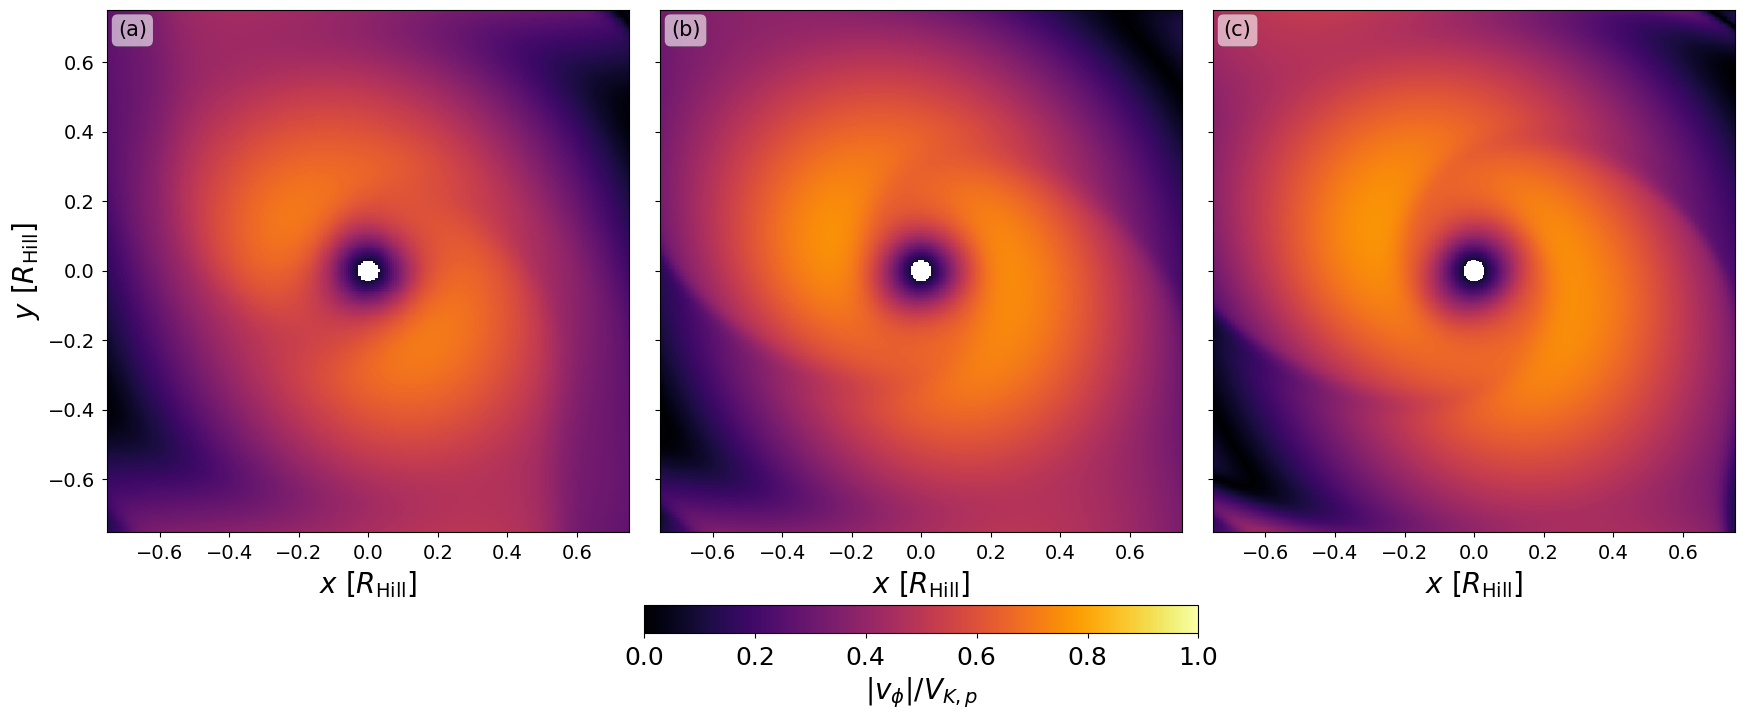

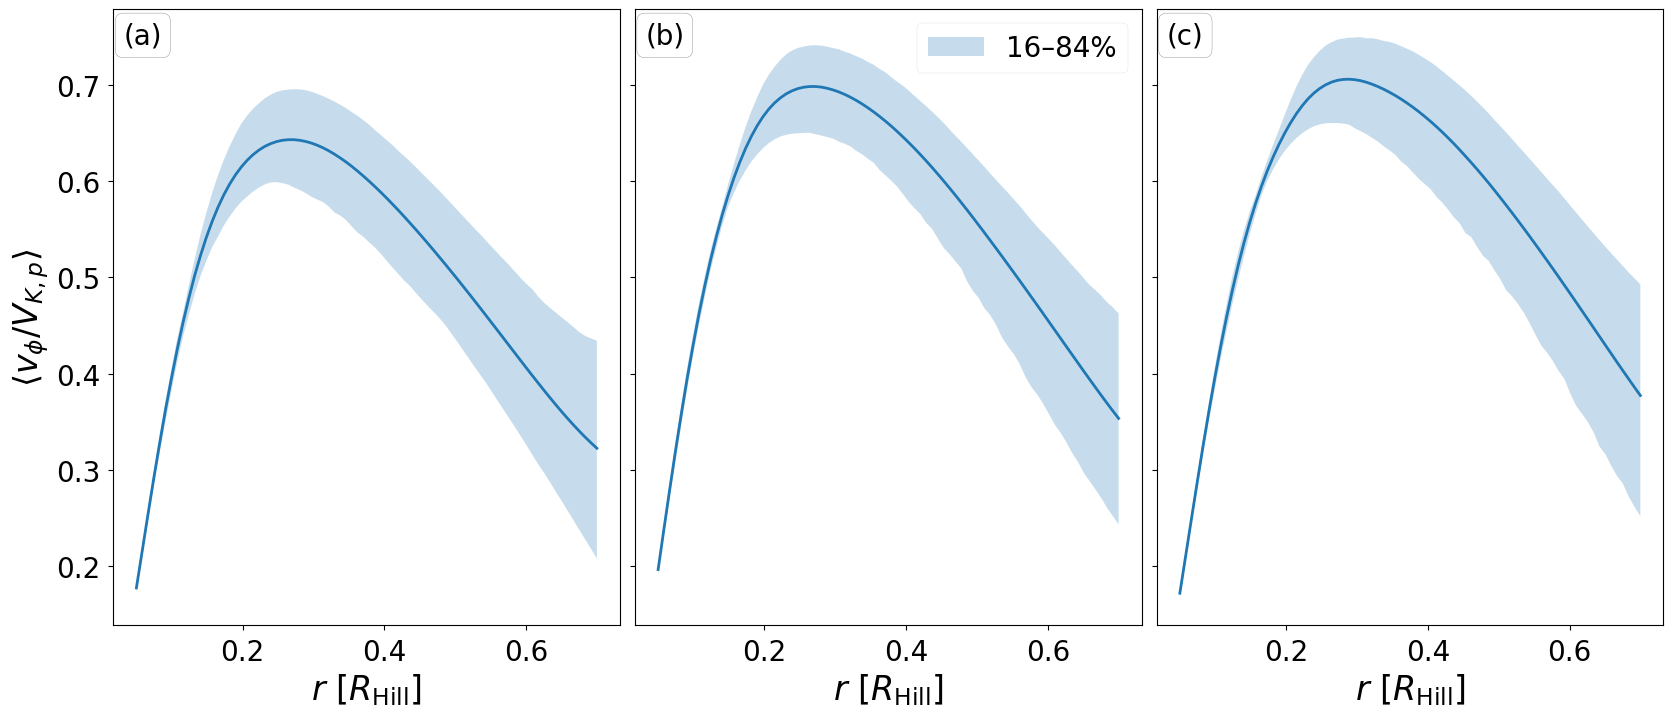

In [3]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors

plt.style.use('seaborn-v0_8-paper')

# =========================
# User settings
# =========================
SNAP = 200

paths = [
    ('fid1', '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'),
    ('fid2', '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'),
    ('fid3', '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs'),
]

# Midplane slice
SLICE_XY = 'theta=1.569,r=[0.8,1.2],phi=[-8.5 deg,8.5 deg]'

# Grid resolution for the 2D map
RES2D = 720

# Radial profile settings (in units of Hill radius)
RMIN_RH = 0.05
RMAX_RH = 0.70
NR = 80
NPHI = 96

# Shared limits for map (so panels comparable)
VMIN, VMAX = 0.0, 1.0
norm_map = colors.Normalize(vmin=VMIN, vmax=VMAX)
CMAP_MAP = 'inferno'

# Physics constants (CGS)
G = 6.67430e-8

panel = ['(a)', '(b)', '(c)']

# =========================
# Precompute a shared uniform grid from fid1 (same as your workflow)
# =========================
label0, path0 = paths[2]
sim0 = fp.Simulation(output_dir=path0)
sim0.units('CGS')
sim0.set_units(UL=34*sim0.AU, UM=0.76*sim0.MSUN)

data0 = sim0.load_field(fields=['gasdens', 'gasv'], snapshot=SNAP, slice=SLICE_XY, interpolate=True)

xmin, xmax = data0.var1_mesh[0].min(), data0.var1_mesh[0].max()
ymin, ymax = data0.var2_mesh[0].min(), data0.var2_mesh[0].max()

xs = np.linspace(xmin, xmax, RES2D)
ys = np.linspace(ymin, ymax, RES2D)
X, Y = np.meshgrid(xs, ys)

# =========================
# FIGURE 1: 2D maps (3 subplots) + shared colorbar
# =========================
plt.close('all')
fig1, axs1 = plt.subplots(
    1, 3,
    figsize=(21, 12),
    sharex=True, sharey=True,
    gridspec_kw=dict(wspace=0.06)
)

pcm_last = None

# store profile results for Figure 2
profiles = []  # list of dicts per fid: r_RH, q_mean, q_p16, q_p84

for i, (ax, (lab, PATH)) in enumerate(zip(axs1, paths)):

    sim = fp.Simulation(output_dir=PATH)
    sim.units('CGS')
    sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

    p = sim.load_planets(snapshot=SNAP)[0]
    xp, yp = p.pos.x, p.pos.y
    RH = p.hill_radius
    Mp_cgs = p.mass * sim.UM

    data = sim.load_field(fields=['gasdens', 'gasv'], snapshot=SNAP, slice=SLICE_XY, interpolate=True)

    # Evaluate velocity on shared grid
    vel = data.evaluate(field='gasv', time=SNAP, var1=X, var2=Y)

    # Velocities in CGS (cm/s)
    vx = vel[0, :] * (sim.UL/sim.UT)
    vy = vel[1, :] * (sim.UL/sim.UT)

    # Planet-centered coordinates
    dx = X - xp
    dy = Y - yp
    r = np.sqrt(dx**2 + dy**2)

    phi = np.arctan2(dy, dx)
    ephix = -np.sin(phi)
    ephiy =  np.cos(phi)

    vphi = vx*ephix + vy*ephiy

    # Keplerian speed around planet
    r_cgs = r * sim.UL
    Vk = np.sqrt(G * Mp_cgs / np.where(r_cgs > 0, r_cgs, np.nan))

    vphi_over_Vk = vphi / Vk

    # mask tiny radii
    vphi_over_Vk = np.where((r / RH) < 0.03, np.nan, vphi_over_Vk)

    # Map coords in R_H
    Xr = dx / RH
    Yr = dy / RH

    pcm_last = ax.pcolormesh(
        Xr, Yr, np.abs(vphi_over_Vk),
        shading='auto',
        cmap=CMAP_MAP,
        norm=norm_map
    )

    ax.set_aspect('equal')
    ax.set_xlim(-0.75, 0.75)
    ax.set_ylim(-0.75, 0.75)
    ax.set_xlabel(r'$x~[R_{\rm Hill}]$', fontsize=20)
    ax.tick_params(labelsize=14)
    ax.grid(False)

    if i == 0:
        ax.set_ylabel(r'$y~[R_{\rm Hill}]$', fontsize=20)

    # panel label
    ax.text(
        0.02, 0.98, panel[i],
        transform=ax.transAxes,
        fontsize=15,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.6)
    )

    # -------------------------
    # Radial profile for this fid (store for Fig 2)
    # -------------------------
    r_RH = np.linspace(RMIN_RH, RMAX_RH, NR)
    r_samp = r_RH * RH
    phi_samp = np.linspace(-np.pi, np.pi, NPHI, endpoint=False)

    RR, PP = np.meshgrid(r_samp, phi_samp, indexing='ij')
    xs_s = xp + RR*np.cos(PP)
    ys_s = yp + RR*np.sin(PP)

    vel_s = data.evaluate(field='gasv', time=SNAP, var1=xs_s, var2=ys_s)

    vx_s = vel_s[0] * (sim.UL/sim.UT)
    vy_s = vel_s[1] * (sim.UL/sim.UT)

    ephix_s = -np.sin(PP)
    ephiy_s =  np.cos(PP)

    vphi_s = vx_s*ephix_s + vy_s*ephiy_s

    r_s_cgs = RR * sim.UL
    Vk_s = np.sqrt(G * Mp_cgs / r_s_cgs)

    q = vphi_s / Vk_s

    q_mean = np.nanmean(q, axis=1)
    q_p16  = np.nanpercentile(q, 16, axis=1)
    q_p84  = np.nanpercentile(q, 84, axis=1)

    profiles.append(dict(label=lab, r_RH=r_RH, q_mean=q_mean, q_p16=q_p16, q_p84=q_p84))

# Shared colorbar at bottom (like your other figures)
cbar1 = fig1.colorbar(
    pcm_last,
    ax=axs1,
    orientation='horizontal',
    location='bottom',
    pad=0.08,
    fraction=0.03,
    aspect=20
)
cbar1.set_label(r'$|v_\phi|/V_{K,p}$', fontsize=20)
cbar1.ax.tick_params(labelsize=18)

plt.show()

# =========================
# FIGURE 2: radial profiles (3 subplots) + shared y
# =========================
plt.close('all')
fig2, axs2 = plt.subplots(
    1, 3,
    figsize=(20, 8),
    sharex=True, sharey=True,
    gridspec_kw=dict(wspace=0.03)
)

for i, (ax, prof) in enumerate(zip(axs2, profiles)):
    r_RH = prof["r_RH"]
    q_mean = prof["q_mean"]
    q_p16 = prof["q_p16"]
    q_p84 = prof["q_p84"]

    ax.plot(r_RH, q_mean, lw=2)
    ax.fill_between(r_RH, q_p16, q_p84, alpha=0.25, label='16–84%')

    ax.set_xlabel(r'$r~[R_{\rm Hill}]$', fontsize=24)
    ax.tick_params(labelsize=20)
    ax.grid(False)

    if i == 0:
        ax.set_ylabel(r'$\langle v_\phi/V_{K,p}\rangle$', fontsize=24)

    ax.text(
        0.02, 0.98, panel[i],
        transform=ax.transAxes,
        fontsize=20,
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.6)
    )

axs2[1].legend(fontsize=20, loc='upper right')

plt.show()


#  Single vertical Mach map with streamlines

Estimate vertical Mach number and plot supersonic contours with streamlines.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


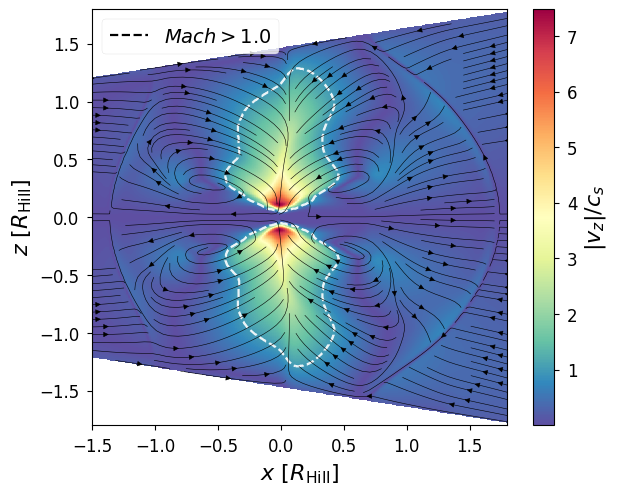

In [ ]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-paper')
from matplotlib.lines import Line2D

# =========================
# Settings
# =========================
PATH = '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
SNAP = 200
res  = 720

# midplane vertical slice
SLICE_XZ = 'phi=0,r=[0.82,1.26]'

# Disk thermodynamics for cs = h(r) vK (around the STAR)
h0    = 0.072
r0_au = 34.0
f     = 1.0

mach_thresh = 1.0  # for Mach_z contour

# =========================
# Simulation
# =========================
sim = fp.Simulation(output_dir=PATH)
sim.units('CGS')
sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

# Planet
p = sim.load_planets(snapshot=SNAP)[0]
xp, yp, zp = p.pos.x, p.pos.y, p.pos.z
RH = p.hill_radius

# =========================
# Load gasv slice (X-Z plane)
# =========================
gasv = sim.load_field('gasv', snapshot=SNAP, slice=SLICE_XZ, interpolate=True)

xmin, xmax = gasv.var1_mesh[0].min(), gasv.var1_mesh[0].max()  # x
zmin, zmax = gasv.var3_mesh[0].min(), gasv.var3_mesh[0].max()  # z

xs = np.linspace(xmin, xmax, res)
zs = np.linspace(-zmax, zmax, res)
X, Z = np.meshgrid(xs, zs)  # (nz,nx)

vel = gasv.evaluate(var1=X, var3=Z, time = SNAP,reflect=True)

# velocity in SI (m/s): (sim.UL/sim.UT) in cm/s -> m/s multiply 1e-2
Vx = vel[0, :] * (sim.UL/sim.UT) * 1e-2
Vz = vel[2, :] * (sim.UL/sim.UT) * 1e-2

# coordinates in AU for plotting Z, and in Hill for x-axis
X_au = X * (sim.UL/sim.AU)
Z_au = Z * (sim.UL/sim.AU)

x_rel = (X - xp) / RH        # (x-xp)/R_H
z_rel = (Z - zp) / RH                # keep z in AU (you can change to z/RH if you want)

# =========================
# Sound speed cs = h(r) vK (STAR) in SI
# Need cylindrical radius from star in this phi=0 slice: R = sqrt(x^2 + y^2)
# here y ~ 0, so R ~ |x| (in code units)
# =========================
G_SI     = 6.67430e-11
Mstar_kg = 0.76 * 1.98847e30
AU_m     = 1.495978707e11

R_au = np.abs(X_au)  # since y~0
R_m  = np.where(R_au > 0, R_au, np.nan) * AU_m

vK = np.sqrt(G_SI * Mstar_kg / R_m)
h_r = h0 * (R_au / r0_au)**f
cs  = h_r * vK

mach_z = np.abs(Vz) / cs

# =========================
# Shock proxy without gasdivv: compression in XZ plane
# div v ~= dVx/dx + dVz/dz  (SI units: 1/s)
# =========================
dx_m = (xs[1] - xs[0]) * sim.UL * 1e-2  # code length -> cm -> m
dz_m = (zs[1] - zs[0]) * sim.UL * 1e-2

dVx_dx = np.gradient(Vx, dx_m, axis=1)  # axis=1 is x
dVz_dz = np.gradient(Vz, dz_m, axis=0)  # axis=0 is z
div_v  = dVx_dx + dVz_dz

compression = np.maximum(0.0, -div_v)   # positive where converging (shock-like)

# =========================
# Plot (choose what you want as heatmap)
# =========================
plt.close('all')
fig, ax = plt.subplots(figsize=(6.7, 5.4))

# --- OPTION A: Mach_z map (your original idea)
heat = mach_z
label = r'$|v_z|/c_s$'

# --- OPTION B: Compression map (better shock proxy)
# heat = compression
# label = r'$\max(0,\,-\nabla\cdot\mathbf{v})\ [{\rm s^{-1}}]$'

pcm = ax.pcolormesh(x_rel, z_rel, heat, shading='auto', cmap='Spectral_r')
cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(label, fontsize=16)
cbar.ax.tick_params(labelsize=12)

# If using Mach_z, add supersonic contour
if heat is mach_z:
    sup = (mach_z > mach_thresh).astype(int)

    ax.contour(
        x_rel, z_rel, sup,
        levels=[0.5],
        colors='white',
        linewidths=1.6,
        linestyles='--',
        alpha=0.9
    )

    # Legend handle manual (API-proof)
    supersonic_handle = Line2D(
        [0], [0],
        color='black',
        lw=1.6,
        ls='--',
        label=rf'$Mach > {mach_thresh:.1f}$'
    )

    ax.legend(
        handles=[supersonic_handle],
        loc='upper left',
        frameon=True,
        fontsize=14
    )


# Streamlines (XZ)
ax.streamplot(x_rel, z_rel, Vx, Vz, density=2, color='k', linewidth=0.4, arrowsize=0.8)

ax.set_xlabel(r'$x~ [R_{\rm Hill}]$', fontsize=16)
ax.set_ylabel(r'$z~ [R_{\rm Hill}]$', fontsize=16)
ax.tick_params(labelsize=12)
ax.set_xlim(-1.5, 1.8)

ax.grid(False)



# =========================
# Text box (upper-right)
# =========================
textstr = (
    rf" fid1_HR$~{SNAP}\ \mathrm{{orbits}}$" "\n"
)




#plt.savefig('media/mach_fid3hr', dpi=300)
plt.show()


#  Multi-run vertical Mach comparison

Compare vertical Mach structure for several simulations using a consistent layout.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.
Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/ou

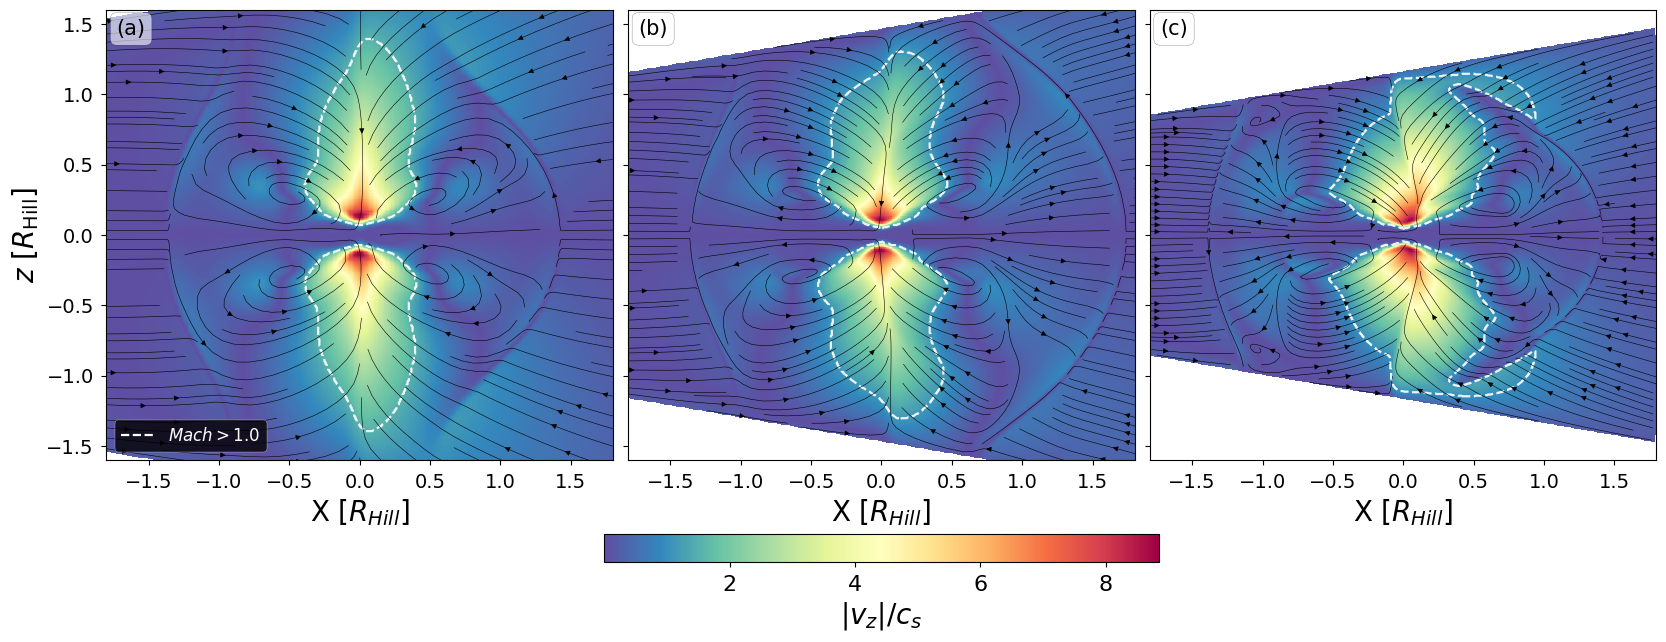

In [1]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-paper')

# =========================
# Settings
# =========================
SNAP = 200
RES  = 720

paths = [
    ('fid1', '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'),
    ('fid2', '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'),
    ('fid3', '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs'),
]

SLICE_XZ = 'phi=0,r=[0.7,1.3]'

h0    = 0.072
r0_au = 34.0
fexp  = 1.0
mach_thresh = 1.0

# =========================
# Constants (SI)
# =========================
G_SI     = 6.67430e-11
Mstar_kg = 0.76 * 1.98847e30
AU_m     = 1.495978707e11

# =========================
# Figure (FIXED LAYOUT)
# =========================
plt.close('all')
fig, axs = plt.subplots(
    1, 3,
    figsize=(20, 12),
    sharex=True,
    sharey=True,
    #constrained_layout=True,          # <-- CLAVE: evita superposiciones
    gridspec_kw=dict(wspace=0.03)     # <-- CLAVE: reduce hueco horizontal
)

pcm_last = None
label_cbar = r'$|v_z|/c_s$'
panel = ['(a)', '(b)', '(c)']
for i, (ax, (lab, PATH)) in enumerate(zip(axs, paths)):
    sim = fp.Simulation(output_dir=PATH)
    sim.units('CGS')
    sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

    p = sim.load_planets(snapshot=SNAP)[0]
    xp, yp, zp = p.pos.x, p.pos.y, p.pos.z
    RH = p.hill_radius

    gasv = sim.load_field('gasv', snapshot=SNAP, slice=SLICE_XZ, interpolate=True)

    xmin, xmax = gasv.var1_mesh[0].min(), gasv.var1_mesh[0].max()
    zmin, zmax = gasv.var3_mesh[0].min(), gasv.var3_mesh[0].max()

    xs = np.linspace(xmin, xmax, RES)
    zs = np.linspace(-zmax, zmax, RES)
    X, Z = np.meshgrid(xs, zs)

    vel = gasv.evaluate(var1=X, var3=Z, time=SNAP, reflect=True)

    # SI (m/s)
    Vx = vel[0, :] * (sim.UL/sim.UT) * 1e-2
    Vz = vel[2, :] * (sim.UL/sim.UT) * 1e-2

    # planet-centered coords in R_H
    x_rel = (X - xp) / RH
    z_rel = (Z - zp) / RH

    # cs = h(r) vK (STAR)
    X_au = X * (sim.UL/sim.AU)
    R_au = np.abs(X_au)
    R_m  = np.where(R_au > 0, R_au, np.nan) * AU_m

    vK = np.sqrt(G_SI * Mstar_kg / R_m)
    h_r = h0 * (R_au / r0_au)**fexp
    cs  = h_r * vK

    mach_z = np.abs(Vz) / cs

    pcm_last = ax.pcolormesh(
        x_rel, z_rel, mach_z,
        shading='auto',
        cmap='Spectral_r'
    )

    # supersonic contour
    sup = (mach_z > mach_thresh).astype(int)
    ax.contour(
        x_rel, z_rel, sup,
        levels=[0.5],
        colors='white',
        linewidths=1.6,
        linestyles='--',
        alpha=0.9
    )

    # streamlines
    ax.streamplot(
        x_rel, z_rel, Vx, Vz,
        density=2.0,
        color='k',
        linewidth=0.4,
        arrowsize=0.8
    )

    
    ax.set_xlabel(r'X [$R_{Hill}$]', fontsize=20)
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.6, 1.6)
    ax.tick_params(labelsize=14)
    ax.grid(False)
    ax.set_aspect('equal')

    ax.text(
        0.02, 0.98,
        panel[i],
        transform=ax.transAxes,
        fontsize=15,
        va='top', ha='left',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='black',
            alpha=0.6
        )
    )

    # Mantén equal, pero sin matar el layout:
    #ax.set_aspect('equal')   # OK con constrained_layout

axs[0].set_ylabel(r'$z~[R_{\rm Hill}]$', fontsize=20)

# Shared colorbar (BOTTOM) - no overlap with constrained_layout + pad
cbar = fig.colorbar(
    pcm_last,
    ax=axs,
    orientation='horizontal',
    location='bottom',
    pad=0.08,        # <-- aumenta separación del panel
    fraction=0.03,
    aspect=20
)
cbar.set_label(label_cbar, fontsize=20)
cbar.ax.tick_params(labelsize=16)

# Legend (solo una vez)
supersonic_handle = Line2D(
    [0], [0],
    color='white',
    lw=1.6,
    ls='--',
    label=rf'$Mach > {mach_thresh:.1f}$'
)
axs[0].legend(
    handles=[supersonic_handle],
    loc='lower left',
    frameon=True,
    fontsize=12,
    labelcolor='white',
    edgecolor='white',
    facecolor='black'
)

plt.show()



#  Vertical compression zones (XZ)

Compute compression proxy $(max(0,-\nabla v))$ and visualize compression zones in the XZ plane.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


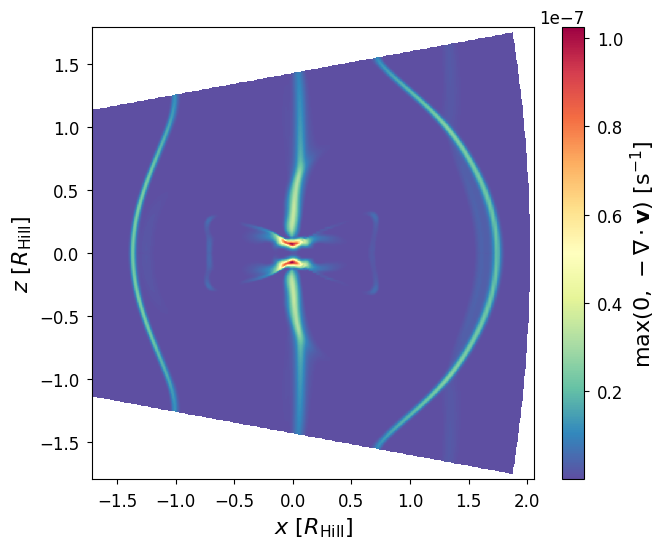

In [2]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-paper')
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# =========================
# Settings
# =========================
PATH = '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
SNAP = 200
RES  = 720

SLICE_XZ = 'phi=0,r=[0.82,1.26]'   # XZ cut at phi=0

# Optional: show only "strong" compression via a contour
COMP_PERC_CONTOUR = None   # e.g. 95, or None

# Gaussian smoothing (in grid cells) — for visualization only
GAUSS_SIGMA = 1.2          # try 0.8–1.2
LOG_VMIN = 1e-9            # only used if USE_LOGNORM=True

# =========================
# Simulation
# =========================
sim = fp.Simulation(output_dir=PATH)
sim.units('CGS')
sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

# Planet
p = sim.load_planets(snapshot = SNAP)[0]
xp, yp, zp = p.pos.x, p.pos.y, p.pos.z
RH = p.hill_radius

# =========================
# Load gasv slice (var1=x, var3=z)
# =========================
gasv = sim.load_field('gasv', snapshot = SNAP, slice=SLICE_XZ, interpolate=True)

xmin, xmax = gasv.var1_mesh[0].min(), gasv.var1_mesh[0].max()  # x
zmin, zmax = gasv.var3_mesh[0].min(), gasv.var3_mesh[0].max()  # z

xs = np.linspace(xmin, xmax, RES)
zs = np.linspace(-zmax, zmax, RES)
X, Z = np.meshgrid(xs, zs)  # (nz, nx)

vel = gasv.evaluate(var1=X, var3=Z, time = SNAP, reflect=True)

# Convert to SI (m/s): sim.UL/sim.UT is cm/s in CGS -> m/s multiply 1e-2
Vx = vel[0, :] * (sim.UL/sim.UT) * 1e-2
Vz = vel[2, :] * (sim.UL/sim.UT) * 1e-2

# Coordinates for plotting (planet-centered, in Hill radii)
x_rel = (X - xp) / RH
z_rel = (Z - zp) / RH

# =========================
# Compression proxy: max(0, -div v) in XZ plane
# div v ≈ dVx/dx + dVz/dz  [1/s]
# =========================
dx_m = (xs[1] - xs[0]) * sim.UL * 1e-2  # code length -> cm -> m
dz_m = (zs[1] - zs[0]) * sim.UL * 1e-2

dVx_dx = np.gradient(Vx, dx_m, axis=1)  # axis=1 is x
dVz_dz = np.gradient(Vz, dz_m, axis=0)  # axis=0 is z

div_v = dVx_dx + dVz_dz
comp  = np.maximum(0.0, -div_v)

# =========================
# Gaussian smoothing (visualization only)
# =========================
comp_s = gaussian_filter(comp, sigma=GAUSS_SIGMA)

# Avoid issues with LogNorm / plotting zeros
floor = 1e-10  # s^-1, por debajo del ruido
comp_plot = np.clip(comp_s, floor, None)
# --- Log scaling

# =========================
# Plot
# =========================
plt.close('all')
fig, ax = plt.subplots(figsize=(6.8, 5.6))



pcm = ax.pcolormesh(
    x_rel, z_rel, comp_plot,
    shading='auto',
    cmap='Spectral_r'
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r'$\max(0,\,-\nabla\cdot\mathbf{v})\ [{\rm s^{-1}}]$', fontsize=16)
cbar.ax.tick_params(labelsize=12)

# Optional contour for strongest compression (based on smoothed field)
if COMP_PERC_CONTOUR is not None:
    thr = np.nanpercentile(comp_plot, COMP_PERC_CONTOUR)
    c1 = ax.contour(
        x_rel, z_rel, comp_plot,
        levels=[thr], colors='w',
        linewidths=1.6, linestyles='--', alpha=0.9
    )
    ax.clabel(c1, fmt={thr: f'>{COMP_PERC_CONTOUR}th perc'}, fontsize=10)

# Optional streamlines (use same coordinates); often looks better with smoothed vectors,
# but leaving as-is:
# ax.streamplot(x_rel, z_rel, Vx, Vz, density=2, color='k', linewidth=0.5, arrowsize=0.8)

ax.set_xlabel(r'$x~ [R_{\rm Hill}]$', fontsize=16)
ax.set_ylabel(r'$z~ [R_{\rm Hill}]$', fontsize=16)
ax.tick_params(labelsize=12)
ax.grid(False)
cbar.ax.yaxis.get_offset_text().set_fontsize(12)

#ax.set_xlim(-0.5, 0.5)
#ax.set_ylim(0,1)



# =========================
# Text box (upper-right)
# =========================
textstr = (
    rf" fid1_HR$~{SNAP}\ \mathrm{{orbits}}$" "\n"
)


plt.tight_layout()
#plt.savefig('media/comp_fid3hr', dpi=300)
plt.show()
    

#  Multi-run compression zone maps

Generate compression maps for several simulations and show a shared colorbar.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.


Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.
Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs'
Found a variables.par file in '/home/alejo/fargo3d/ou

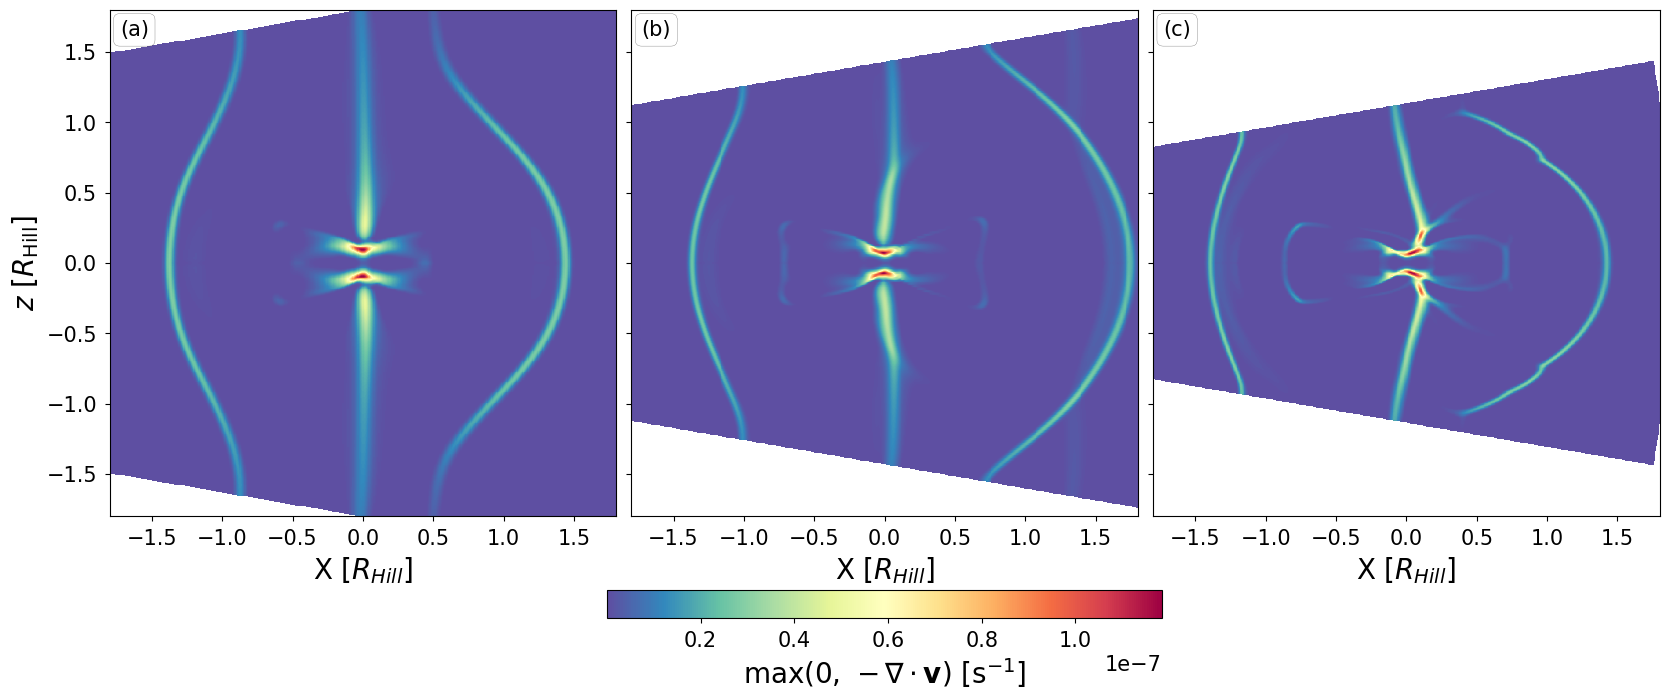

In [86]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

plt.style.use('seaborn-v0_8-paper')

# =========================
# Settings
# =========================
SNAP = 200
RES  = 720

paths = [
    ('fid1', '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'),
    ('fid2', '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'),
    ('fid3', '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs'),
]

SLICE_XZ = 'phi=0,r=[0.7,1.3]'   # XZ cut at phi=0

# Optional: show only "strong" compression via a contour
COMP_PERC_CONTOUR = None   # e.g. 95, or None

# Gaussian smoothing (in grid cells) — for visualization only
GAUSS_SIGMA = 1.2

# floor to avoid zeros
FLOOR = 1e-10  # s^-1

# Panel labels
panel = ['(a)', '(b)', '(c)']

# =========================
# Figure: match your spacing/layout
# =========================
plt.close('all')
fig, axs = plt.subplots(
    1, 3,
    figsize=(20, 12),
    sharex=True,
    sharey=True,
    gridspec_kw=dict(wspace=0.03)
)

pcm_last = None
cbar_label = r'$\max(0,\,-\nabla\cdot\mathbf{v})\ [{\rm s^{-1}}]$'

for i, (ax, (lab, PATH)) in enumerate(zip(axs, paths)):

    # -------------------------
    # Simulation
    # -------------------------
    sim = fp.Simulation(output_dir=PATH)
    sim.units('CGS')
    sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

    # Planet
    p = sim.load_planets(snapshot=SNAP)[0]
    xp, yp, zp = p.pos.x, p.pos.y, p.pos.z
    RH = p.hill_radius

    # -------------------------
    # Load gasv slice (var1=x, var3=z)
    # -------------------------
    gasv = sim.load_field('gasv', snapshot=SNAP, slice=SLICE_XZ, interpolate=True)

    xmin, xmax = gasv.var1_mesh[0].min(), gasv.var1_mesh[0].max()
    zmin, zmax = gasv.var3_mesh[0].min(), gasv.var3_mesh[0].max()

    xs = np.linspace(xmin, xmax, RES)
    zs = np.linspace(-zmax, zmax, RES)
    X, Z = np.meshgrid(xs, zs)

    vel = gasv.evaluate(var1=X, var3=Z, time=SNAP, reflect=True)

    # Convert to SI (m/s)
    Vx = vel[0, :] * (sim.UL/sim.UT) * 1e-2
    Vz = vel[2, :] * (sim.UL/sim.UT) * 1e-2

    # Planet-centered coords in R_H
    x_rel = (X - xp) / RH
    z_rel = (Z - zp) / RH

    # -------------------------
    # Compression proxy: max(0, -div v) in XZ
    # div v ≈ dVx/dx + dVz/dz  [1/s]
    # -------------------------
    dx_m = (xs[1] - xs[0]) * sim.UL * 1e-2
    dz_m = (zs[1] - zs[0]) * sim.UL * 1e-2

    dVx_dx = np.gradient(Vx, dx_m, axis=1)
    dVz_dz = np.gradient(Vz, dz_m, axis=0)
    div_v  = dVx_dx + dVz_dz
    comp   = np.maximum(0.0, -div_v)

    # Smooth (viz only) + floor
    comp_s    = gaussian_filter(comp, sigma=GAUSS_SIGMA)
    comp_plot = np.clip(comp_s, FLOOR, None)

    # -------------------------
    # Plot
    # -------------------------
    pcm_last = ax.pcolormesh(
        x_rel, z_rel, comp_plot,
        shading='auto',
        cmap='Spectral_r'
    )

    # Optional contour for strongest compression
    if COMP_PERC_CONTOUR is not None:
        thr = np.nanpercentile(comp_plot, COMP_PERC_CONTOUR)
        c1 = ax.contour(
            x_rel, z_rel, comp_plot,
            levels=[thr], colors='w',
            linewidths=1.6, linestyles='--', alpha=0.9
        )
        ax.clabel(c1, fmt={thr: f'>{COMP_PERC_CONTOUR}th perc'}, fontsize=10)

    # Axis cosmetics to match your Mach figure
    ax.set_xlabel(r'X [$R_{Hill}$]', fontsize=20)
    ax.set_xlim(-1.8, 1.8)
    ax.set_ylim(-1.8, 1.8)
    ax.tick_params(labelsize=15)
    ax.grid(False)
    ax.set_aspect('equal')
    

    # Panel label
    ax.text(
        0.02, 0.98, panel[i],
        transform=ax.transAxes,
        fontsize=15,
        va='top', ha='left',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='black',
            alpha=0.6
        )
    )

axs[0].set_ylabel(r'$z~[R_{\rm Hill}]$', fontsize=20)

# =========================
# Shared colorbar (BOTTOM), same geometry as your Mach plot
# =========================
cbar = fig.colorbar(
    pcm_last,
    ax=axs,
    orientation='horizontal',
    location='bottom',
    pad=0.08,
    fraction=0.03,
    aspect=20
)

cbar.set_label(cbar_label, fontsize=20)
cbar.ax.tick_params(labelsize=15)

# Fix offset text size if Matplotlib uses scientific notation
cbar.ax.xaxis.get_offset_text().set_fontsize(15)

plt.show()


#  Accreted mass and accretion rate

Compute enclosed mass vs time and estimate accretion rates using smoothing filters.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.


100%|██████████| 6/6 [04:13<00:00, 42.26s/it]


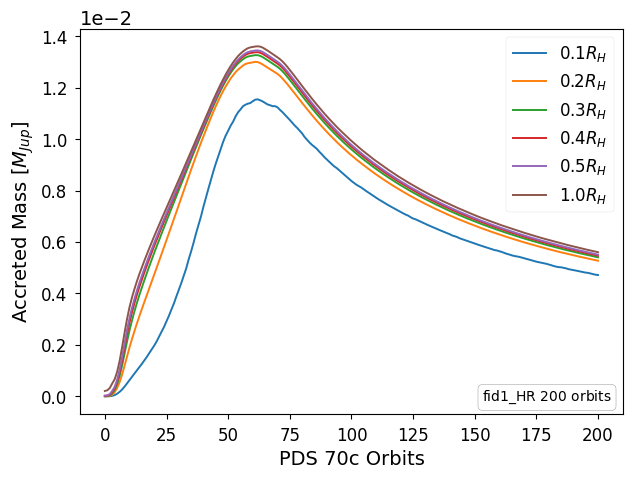

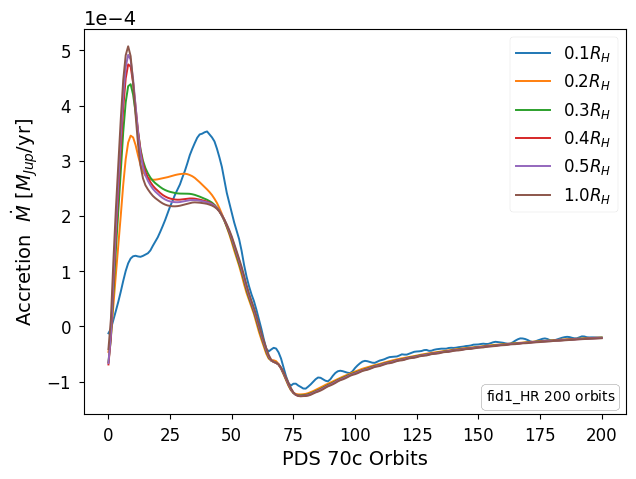

In [ ]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from scipy.signal import savgol_filter

plt.style.use('seaborn-v0_8-paper')

# =========================
# Settings
# =========================
PATH = '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
SNAP = 200
MJUP = 1.898e30

RADIUS_FACTORS = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 1.0])

# Derivative smoothing (Savitzky–Golay)
SG_WINDOW = 11   # must be odd; auto-adjusted if SNAP small
SG_POLY   = 3

# If each snapshot is ~1 orbit in your outputs, keep dt=1.
# Otherwise replace with your real time array (e.g., sim.time(snapshot=s) converted to orbits).
time = np.arange(SNAP + 1, dtype=float)  # "orbits"
dt = np.gradient(time)

# =========================
# Simulation
# =========================
sim = fp.Simulation(output_dir=PATH)
sim.units('CGS')
sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

# Planet reference snapshot (used to build initial sphere object, per your workflow)
planet = sim.load_planets(snapshot = SNAP)[0]
xp, yp, zp = planet.pos.x, planet.pos.y, planet.pos.z

# Pre-allocate
mass = np.zeros((len(RADIUS_FACTORS), SNAP + 1), dtype=float)

# =========================
# Enclosed mass vs time (your method)
# =========================
for i in tqdm.tqdm(range(len(RADIUS_FACTORS))):
    radius = planet.hill_radius * RADIUS_FACTORS[i]
    sphere = fp.Surface(
        type='sphere',
        center=(xp, yp, zp),
        radius=radius,
        subdivisions=6,
        z_cut=0  # hemisphere; you later multiply by 2
    )
    mass[i] = sphere.total_mass(sim, snapshot=[0, SNAP])

# Convert to MJup (and to full sphere if z_cut=0 means half-domain)
M_mjup = 2.0 * mass * sim.UM / MJUP  # [MJup]

# =========================
# Accretion rate: dM/dt (smoothed)
# =========================
# Ensure SG window is valid (odd, <= N)
N = SNAP + 1
w = min(SG_WINDOW, N if N % 2 == 1 else N - 1)
if w < 5:  # too few points; fall back to raw gradient
    w = None

Mdot_mjup_per_orbit = np.zeros_like(M_mjup)

for i in range(len(RADIUS_FACTORS)):
    Mi = M_mjup[i]

    if w is not None:
        Mi_s = savgol_filter(Mi, window_length=w, polyorder=min(SG_POLY, w - 2))
    else:
        Mi_s = Mi

    # derivative consistent with non-uniform time if you later replace `time`
    Mdot_mjup_per_orbit[i] = np.gradient(Mi_s, time)

# =========================
# Plot M(t)
# =========================
fig, ax = plt.subplots(figsize=(7, 5))
for i, f in enumerate(RADIUS_FACTORS):
    ax.plot(time, M_mjup[i], label=rf'{f}$R_H$')
ax.set_xlabel('PDS 70c Orbits', fontsize=14)
ax.set_ylabel(r'Accreted Mass [$M_{Jup}$]', fontsize=14)
#ax.set_title(rf"fid3_HR$~{SNAP}\ \mathrm{{orbits}}$", fontsize=14)
ax.tick_params(labelsize=12)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.yaxis.get_offset_text().set_fontsize(14)
ax.legend(fontsize=12)

textstr = rf"fid1_HR$~{SNAP}\ \mathrm{{orbits}}$"
ax.text(
    0.98, 0.02, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='bottom', ha='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.6)
)

#plt.savefig("media/mass_fid3hr.png", dpi=300, bbox_inches="tight")
plt.show()
# =========================
# Plot dM/dt
# =========================
fig, ax = plt.subplots(figsize=(7, 5))
for i, f in enumerate(RADIUS_FACTORS):
    ax.plot(time, Mdot_mjup_per_orbit[i], label=rf'{f}$R_H$')

ax.set_xlabel('PDS 70c Orbits', fontsize=14)
ax.set_ylabel(r'Accretion  $\dot{M}$ [$M_{Jup}$/yr]', fontsize=14)
#ax.set_title(rf"fid1_HR$~{SNAP}\ \mathrm{{orbits}}$", fontsize=14)
ax.tick_params(labelsize=12)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.yaxis.get_offset_text().set_fontsize(14)
ax.legend(fontsize=12)

ax.text(
    0.98, 0.02, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='bottom', ha='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.6)
)

#plt.savefig("media/mdot_fid3hr.png", dpi=300, bbox_inches="tight")
plt.show()

#  Accretion metrics across simulations

Compute robust tail-window statistics for mass and accretion rates and collect results in a DataFrame.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid1_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.002512, 0.0], Mass: 0.002512
Units set to CGS.


fid1: M(t):   0%|          | 0/5 [00:00<?, ?it/s]

fid1: M(t): 100%|██████████| 5/5 [02:52<00:00, 34.46s/it]


Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


fid2: M(t): 100%|██████████| 5/5 [03:35<00:00, 43.11s/it]


Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.010048, 0.0], Mass: 0.010048
Units set to CGS.


fid3: M(t): 100%|██████████| 5/5 [04:53<00:00, 58.74s/it]


=== Robust final (tail) summary: per sim, per R/RH ===
     sim  R_over_RH    R_code  M_tail_median_MJup  M_tail_mean_MJup  \
0   fid1       0.15  0.013954            0.005816          0.005869   
1   fid1       0.30  0.027907            0.006140          0.006196   
2   fid1       0.40  0.037209            0.006213          0.006269   
3   fid1       0.50  0.046512            0.006257          0.006313   
4   fid1       1.00  0.093024            0.006363          0.006421   
5   fid2       0.15  0.017714            0.009096          0.009180   
6   fid2       0.30  0.035428            0.009616          0.009739   
7   fid2       0.40  0.047237            0.009725          0.009856   
8   fid2       0.50  0.059047            0.009784          0.009919   
9   fid2       1.00  0.118093            0.009865          0.010008   
10  fid3       0.15  0.022095            0.016380          0.016381   
11  fid3       0.30  0.044191            0.017266          0.017334   
12  fid3       0.40  

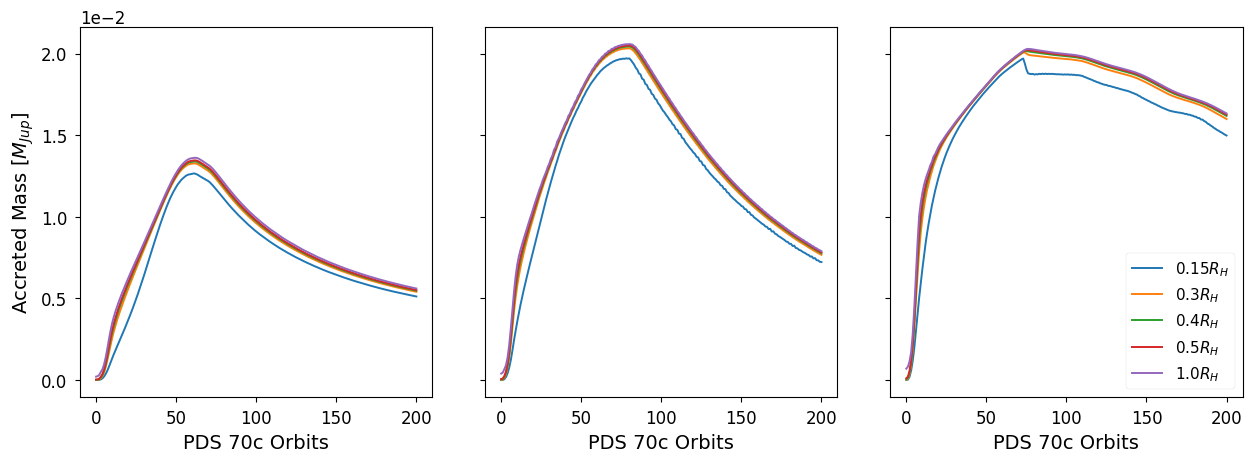

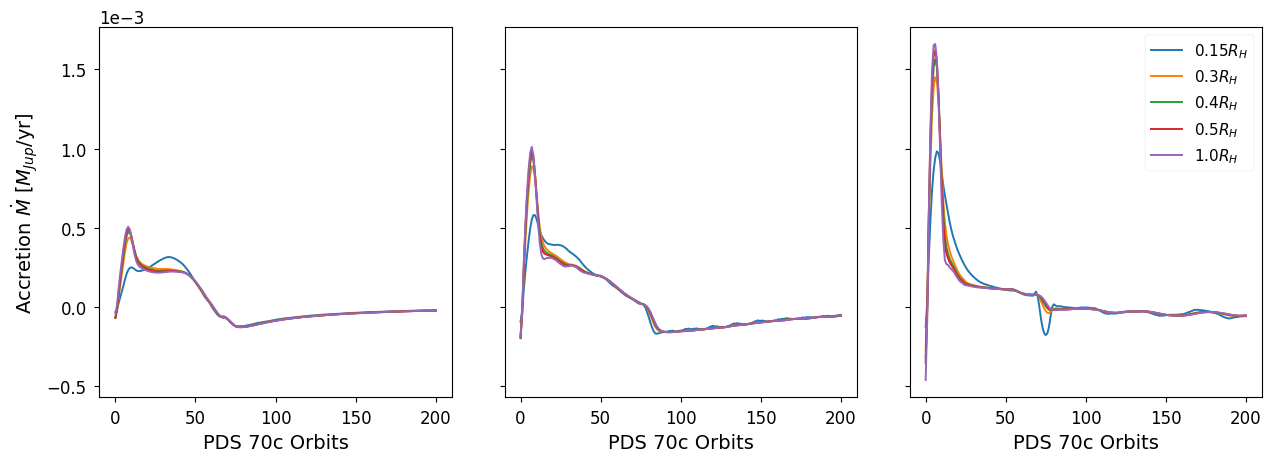

In [13]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from scipy.signal import savgol_filter
import pandas as pd

plt.style.use("seaborn-v0_8-paper")

# =========================
# Global settings
# =========================
SNAP = 200
MJUP = 1.898e30

RADIUS_FACTORS = np.array([0.15, 0.3, 0.4, 0.5, 1.0])

# Savitzky–Golay (for smoothing before derivative)
SG_WINDOW = 11
SG_POLY   = 3

# Time array (orbits)
time = np.arange(SNAP + 1, dtype=float)

# Robust "final" window: last fraction of snapshots
TAIL_FRAC = 0.30  # last 30%

# Simulation paths
paths = [
    ("fid1", "/home/alejo/fargo3d/outputs/pds70hr_fid1_rs"),
    ("fid2", "/home/alejo/fargo3d/outputs/pds70hr_fid2_rs"),
    ("fid3", "/home/alejo/fargo3d/outputs/pds70hr_fid3_rs"),
]

# =========================
# Helpers
# =========================
def tail_window_indices(N, tail_frac=0.3):
    i0 = int(np.floor((1.0 - tail_frac) * (N - 1)))
    i1 = N
    return i0, i1

def robust_stats_over_tail(arr_2d, tail_frac=0.3):
    """
    arr_2d: (NR, N) -> returns per-radius robust stats on the tail window.
    """
    NR, N = arr_2d.shape
    i0, i1 = tail_window_indices(N, tail_frac=tail_frac)
    X = arr_2d[:, i0:i1]

    out = {
        "i0": i0, "i1": i1,
        "mean":   np.nanmean(X, axis=1),
        "median": np.nanmedian(X, axis=1),
        "p16":    np.nanpercentile(X, 16, axis=1),
        "p84":    np.nanpercentile(X, 84, axis=1),
        "std":    np.nanstd(X, axis=1),
    }
    return out

# =========================
# Storage for plots
# =========================
M_all    = []   # list of (NR, N) mass vs time (MJup)
Mdot_all = []   # list of (NR, N) dM/dt vs time (MJup/orbit)

# Rows for tidy summary DataFrame
rows = []

# =========================
# Loop over simulations
# =========================
for label, PATH in paths:
    sim = fp.Simulation(output_dir=PATH)
    sim.units("CGS")
    sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

    planet = sim.load_planets(snapshot=SNAP)[0]
    xp, yp, zp = planet.pos.x, planet.pos.y, planet.pos.z
    RH = planet.hill_radius

    # ---- M(t) for each radius factor ----
    mass_code = np.zeros((len(RADIUS_FACTORS), SNAP + 1), dtype=float)

    for i in tqdm.tqdm(range(len(RADIUS_FACTORS)), desc=f"{label}: M(t)"):
        radius = RH * RADIUS_FACTORS[i]
        sphere = fp.Surface(
            type="sphere",
            center=(xp, yp, zp),
            radius=radius,
            subdivisions=6,
            z_cut=0
        )
        mass_code[i] = sphere.total_mass(sim, snapshot=[0, SNAP])

    # Convert to MJup and to full sphere (z_cut=0 -> hemisphere)
    M_mjup = 2.0 * mass_code * sim.UM / MJUP
    M_all.append(M_mjup)

    # ---- dM/dt (MJup/orbit) ----
    N = SNAP + 1
    w = min(SG_WINDOW, N if N % 2 == 1 else N - 1)
    if w < 5:
        w = None

    Mdot = np.zeros_like(M_mjup)
    for i in range(len(RADIUS_FACTORS)):
        Mi = M_mjup[i]
        if w is not None:
            Mi_s = savgol_filter(Mi, window_length=w, polyorder=min(SG_POLY, w - 2))
        else:
            Mi_s = Mi
        Mdot[i] = np.gradient(Mi_s, time)

    Mdot_all.append(Mdot)

    # =========================
    # Robust final stats (tail window) for M and Mdot
    # =========================
    M_stats    = robust_stats_over_tail(M_mjup, tail_frac=TAIL_FRAC)
    Mdot_stats = robust_stats_over_tail(Mdot,   tail_frac=TAIL_FRAC)

    # Store one row per radius
    for k, f in enumerate(RADIUS_FACTORS):
        rows.append({
            "sim": label,
            "R_over_RH": float(f),
            "R_code": float(f * RH),

            # Mass robust final (MJup)
            "M_tail_median_MJup": float(M_stats["median"][k]),
            "M_tail_mean_MJup":   float(M_stats["mean"][k]),
            "M_tail_p16_MJup":    float(M_stats["p16"][k]),
            "M_tail_p84_MJup":    float(M_stats["p84"][k]),
            "M_tail_std_MJup":    float(M_stats["std"][k]),

            # Accretion robust final (MJup/orbit)
            "Mdot_tail_median_MJup_per_orbit": float(Mdot_stats["median"][k]),
            "Mdot_tail_mean_MJup_per_orbit":   float(Mdot_stats["mean"][k]),
            "Mdot_tail_p16_MJup_per_orbit":    float(Mdot_stats["p16"][k]),
            "Mdot_tail_p84_MJup_per_orbit":    float(Mdot_stats["p84"][k]),
            "Mdot_tail_std_MJup_per_orbit":    float(Mdot_stats["std"][k]),

            # window bookkeeping
            "tail_frac": float(TAIL_FRAC),
            "tail_i0": int(M_stats["i0"]),
            "tail_i1": int(M_stats["i1"]),
        })

# =========================
# DataFrame (tidy) + optional wide view
# =========================
df = pd.DataFrame(rows).sort_values(["sim", "R_over_RH"]).reset_index(drop=True)

print("\n=== Robust final (tail) summary: per sim, per R/RH ===")
print(df)

# Optional: wide table for mass median
df_mass_med_wide = df.pivot(index="R_over_RH", columns="sim", values="M_tail_median_MJup").reset_index()
print("\n=== Wide view: M_tail_median_MJup ===")
print(df_mass_med_wide)

# Optional: wide table for mdot mean
df_mdot_mean_wide = df.pivot(index="R_over_RH", columns="sim", values="Mdot_tail_mean_MJup_per_orbit").reset_index()
print("\n=== Wide view: Mdot_tail_mean_MJup_per_orbit ===")
print(df_mdot_mean_wide)

# =========================
# FIGURE 1: M(t)
# =========================
fig1, axs1 = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, (label, _), M_mjup in zip(axs1, paths, M_all):
    for k, f in enumerate(RADIUS_FACTORS):
        ax.plot(time, M_mjup[k], label=rf"{f}$R_H$")

    ax.set_xlabel("PDS 70c Orbits", fontsize=14)
    ax.tick_params(labelsize=12)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(12)

axs1[0].set_ylabel(r"Accreted Mass [$M_{Jup}$]", fontsize=14)
axs1[-1].legend(fontsize=11, loc="lower right")
fig1.subplots_adjust(wspace=0.15)
plt.show()

# =========================
# FIGURE 2: dM/dt
# =========================
fig2, axs2 = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, (label, _), Mdot in zip(axs2, paths, Mdot_all):
    for k, f in enumerate(RADIUS_FACTORS):
        ax.plot(time, Mdot[k], label=rf"{f}$R_H$")

    ax.set_xlabel("PDS 70c Orbits", fontsize=14)
    ax.tick_params(labelsize=12)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(12)

axs2[0].set_ylabel(r"Accretion $\dot{M}$ [$M_{Jup}$/yr]", fontsize=14)
axs2[-1].legend(fontsize=11, loc="upper right")
fig2.subplots_adjust(wspace=0.15)
plt.show()


In [14]:
df

,sim,R_over_RH,R_code,M_tail_median_MJup,M_tail_mean_MJup,M_tail_p16_MJup,M_tail_p84_MJup,M_tail_std_MJup,Mdot_tail_median_MJup_per_orbit,Mdot_tail_mean_MJup_per_orbit,Mdot_tail_p16_MJup_per_orbit,Mdot_tail_p84_MJup_per_orbit,Mdot_tail_std_MJup_per_orbit,tail_frac,tail_i0,tail_i1
0,fid1,0.15,0.013954,0.005816,0.005869,0.005316,0.006459,0.000497,-0.000027,-0.000028,-0.000036,-0.000022,0.000006,0.3,140,201
1,fid1,0.30,0.027907,0.006140,0.006196,0.005614,0.006817,0.000524,-0.000029,-0.000030,-0.000038,-0.000023,0.000007,0.3,140,201
2,fid1,0.40,0.037209,0.006213,0.006269,0.005680,0.006896,0.000530,-0.000030,-0.000030,-0.000038,-0.000023,0.000007,0.3,140,201
3,fid1,0.50,0.046512,0.006257,0.006313,0.005721,0.006944,0.000533,-0.000030,-0.000031,-0.000038,-0.000023,0.000007,0.3,140,201
4,fid1,1.00,0.093024,0.006363,0.006421,0.005819,0.007061,0.000541,-0.000030,-0.000031,-0.000039,-0.000023,0.000007,0.3,140,201
5,fid2,0.15,0.017714,0.009096,0.009180,0.007737,0.010704,0.001292,-0.000073,-0.000074,-0.000089,-0.000057,0.000016,0.3,140,201
6,fid2,0.30,0.035428,0.009616,0.009739,0.008224,0.011344,0.001358,-0.000075,-0.000078,-0.000095,-0.000061,0.000015,0.3,140,201
7,fid2,0.40,0.047237,0.009725,0.009856,0.008326,0.011478,0.001372,-0.000075,-0.000078,-0.000096,-0.000062,0.000015,0.3,140,201
8,fid2,0.50,0.059047,0.009784,0.009919,0.008380,0.011550,0.001379,-0.000075,-0.000079,-0.000097,-0.000062,0.000016,0.3,140,201
9,fid2,1.00,0.118093,0.009865,0.010008,0.008459,0.011653,0.001388,-0.000076,-0.000079,-0.000097,-0.000062,0.000016,0.3,140,201


#  Mollweide single-mass map

Build Mollweide projections of surface flux on a sphere and annotate star direction.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70lr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70lr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 32 [[0, np.float64(-2.999667883078125)], [-1, np.float64(2.99966788307813)]]
	Variable r: 64 [[0, np.float64(0.41696039685877606)], [-1, np.float64(1.9218272223671455)]]
	Variable theta: 128 [[0, np.float64(1.4006671731515232)], [-1, np.float64(1.5701291536384767)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


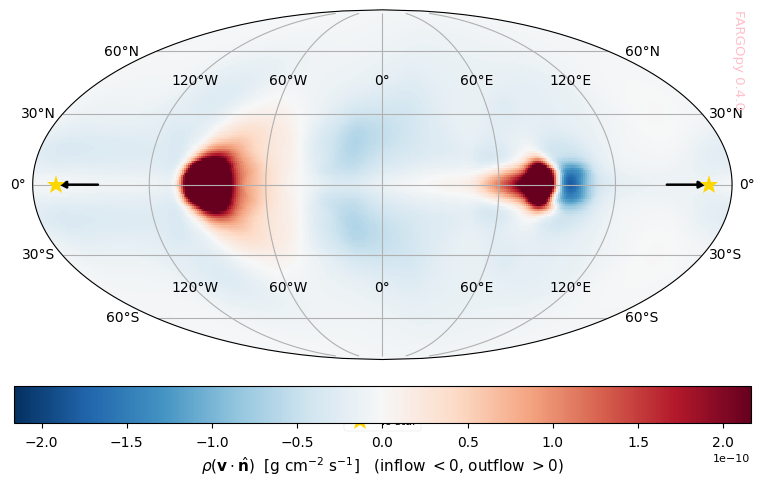

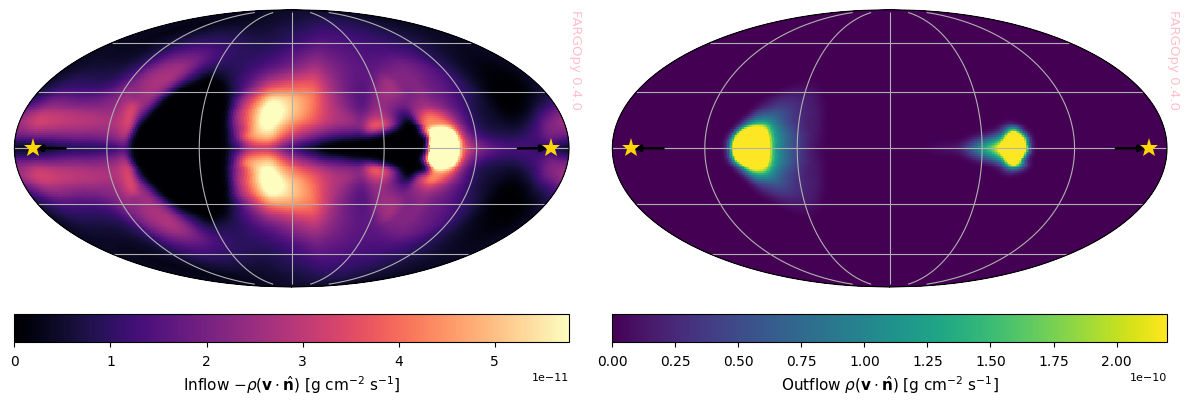

In [1]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter, median_filter
import cartopy.crs as ccrs

plt.style.use("seaborn-v0_8-paper")

# =========================
# CONFIGURATION
# =========================
PATH = "/home/alejo/fargo3d/outputs/pds70lr_fid2_rs"
SNAP = 50

# Sphere and cut radii in Hill radii
RSPH_FRAC = 0.6 # flux sphere radius
RCUT_FRAC = RSPH_FRAC+0.1  # data cut radius
SUBDIVISIONS = 5  # sphere tessellation level

# Smoothing parameters
SIGMA_LON = 2.5   # pixels in longitude
SIGMA_LAT = 1.5   # pixels in latitude
USE_MEDIAN = True
MED_SIZE = (3, 3)

# Regular grid for Mollweide map
NLON = 360
NLAT = 180

# Robust color limits
PCTL_VMAX_SIGNED = 99.0   # for signed diverging map
PCTL_VMAX_POS    = 99.0   # for inflow/outflow maps (positive-only)

# Colormaps
CMAP_SIGNED = "RdBu_r"
CMAP_IN     = "magma"
CMAP_OUT    = "viridis"

# =========================
# STAR DIRECTION (planet at x>0, star at origin) => lon = ±180, lat=0
# We draw an arrow that points to the seam and then place a star *inside* the map,
# so it is not clipped by the Mollweide boundary.
# =========================
STAR_LON = 180.0
STAR_LAT = 0.0
STAR_LABEL = "To star"

def add_star_arrow_pm180(ax,
                         lon_deg=STAR_LON, lat_deg=STAR_LAT,
                         label=STAR_LABEL,
                         dlon_inside=15.0,  # how far inside the map the star sits (deg)
                         dlon_tail=30.0,    # how far inside the tail starts (deg)
                         tail_lat_offset=0.0,
                         draw_meridian=False):
    """
    Draw a directional arrow towards the Mollweide seam (±180°) and put the star
    slightly inside the map to avoid clipping.

    We draw it twice: at +180 and at -180 (seam repetition).
    """
    # seam reps: +180 and -180
    seam_lons = [lon_deg, lon_deg - 360.0]  # 180 and -180

    for k, Lseam in enumerate(seam_lons):
        # Put the star slightly INSIDE the boundary (avoid clipping)
        # If seam is +180, inside is 180 - dlon_inside; if seam is -180, inside is -180 + dlon_inside
        if Lseam > 0:
            L_star = Lseam - dlon_inside
            L_tail = Lseam - dlon_tail
        else:
            L_star = Lseam + dlon_inside
            L_tail = Lseam + dlon_tail

        lat0 = lat_deg + tail_lat_offset

        # --- Arrow (tail -> head at star) ---
        ax.annotate(
            "",
            xy=(L_star, lat_deg),
            xytext=(L_tail, lat0),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            arrowprops=dict(arrowstyle="-|>", lw=1.8, color="k"),
            zorder=12
        )

        # --- Star marker at arrow tip (inside the map, not on the boundary) ---
        ax.plot(
            L_star, lat_deg,
            marker="*", markersize=14,
            markeredgecolor="k", markerfacecolor="gold",
            transform=ccrs.PlateCarree(),
            zorder=13,
            label=label if k == 0 else None
        )

        # Optional: meridian line at seam (usually not needed if arrow exists)
        if draw_meridian:
            ax.plot(
                [Lseam, Lseam], [-90, 90],
                transform=ccrs.PlateCarree(),
                linewidth=1.2, linestyle="--", color="k", alpha=0.5,
                zorder=8
            )

# =========================
# SIMULATION
# =========================
sim = fp.Simulation(output_dir=PATH)
sim.units("CGS")
sim.set_units(UL=34 * sim.AU, UM=0.76 * sim.MSUN)

# =========================
# Planet parameters
# =========================
p = sim.load_planets()[0]
xp, yp = p.pos.x, p.pos.y
rhill = p.hill_radius

# =========================
# Load cut sphere data
# =========================
cut_sphere = (xp, yp, 0.0, RCUT_FRAC * rhill)

data = sim.load_field(
    fields=["gasdens", "gasv"],
    snapshot = SNAP,
    cut=cut_sphere,
    interpolate=True
)

# =========================
# Surface sphere (flux computed here)
# =========================
sphere = fp.Surface(
    type="sphere",
    center=(xp, yp, 0.0),
    radius=RSPH_FRAC * rhill,
    subdivisions=SUBDIVISIONS
)

xcs, ycs, zcs = sphere.centers[:, 0], sphere.centers[:, 1], sphere.centers[:, 2]

# =========================
# Evaluate density and velocity on triangle centers
# =========================
rhoc = data.evaluate(
    field="gasdens",
    var1=xcs, var2=ycs, var3=zcs,
    reflect=True,
    time = SNAP
)

velc = data.evaluate(
    field="gasv",
    var1=xcs, var2=ycs, var3=zcs,
    reflect=True,
    time = SNAP
)

# =========================
# Signed normal mass flux per unit area:
#   F = rho * (v · n)
# Outward normals -> F<0 inflow, F>0 outflow
# Units: g cm^-2 s^-1
# =========================
velc_arr = np.asarray(velc)
if velc_arr.ndim == 2 and velc_arr.shape[0] == 3:
    velc_arr = velc_arr.T  # (N,3)

normals = np.asarray(sphere.normals)
if normals.ndim == 2 and normals.shape[0] == 3:
    normals = normals.T     # (N,3)

vn = np.einsum("ij,ij->i", velc_arr, normals)
F = np.asarray(rhoc).ravel() * vn * sim.UM / (sim.UL**2 * sim.UT)  # signed

Fin  = np.maximum(-F, 0.0)  # inflow magnitude (>=0)
Fout = np.maximum( F, 0.0)  # outflow magnitude (>=0)

# =========================
# Convert sphere points to lon/lat (degrees), centered on planet
# =========================
x = xcs - xp
y = ycs - yp
z = zcs

r = np.sqrt(x**2 + y**2 + z**2)
lat = np.degrees(np.arcsin(z / r))          # [-90, 90]
lon = np.degrees(np.arctan2(y, x))          # [-180, 180]
pts = np.column_stack([lon, lat])

# =========================
# Regular lon/lat grid
# =========================
lon_grid = np.linspace(-180.0, 180.0, NLON, endpoint=False)
lat_grid = np.linspace(-90.0,  90.0,  NLAT)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

def regrid_and_smooth(vals):
    """Interpolate vals(lon,lat) from irregular pts -> regular grid, fill NaNs, smooth."""
    Z_lin  = griddata(pts, vals, (LON, LAT), method="linear", fill_value=np.nan)
    Z_near = griddata(pts, vals, (LON, LAT), method="nearest")
    Z = np.where(np.isfinite(Z_lin), Z_lin, Z_near)

    if USE_MEDIAN:
        Z = median_filter(Z, size=MED_SIZE, mode="nearest")

    Zs = gaussian_filter(Z, sigma=(SIGMA_LAT, SIGMA_LON), mode=("reflect", "wrap"))
    return Zs

Z_signed = regrid_and_smooth(F)
Z_in     = regrid_and_smooth(Fin)
Z_out    = regrid_and_smooth(Fout)

# =========================
# Color scaling
# =========================
vmax_signed = np.nanpercentile(np.abs(Z_signed), PCTL_VMAX_SIGNED)
if not np.isfinite(vmax_signed) or vmax_signed == 0:
    vmax_signed = 1.0

vmax_in  = np.nanpercentile(Z_in,  PCTL_VMAX_POS)
vmax_out = np.nanpercentile(Z_out, PCTL_VMAX_POS)
if not np.isfinite(vmax_in)  or vmax_in  == 0: vmax_in  = 1.0
if not np.isfinite(vmax_out) or vmax_out == 0: vmax_out = 1.0

# ============================================================
# FIGURE 1 (PRIMARY): single diverging Mollweide (signed flux)
# ============================================================
fig1 = plt.figure(figsize=(8, 5))
ax = plt.axes(projection=ccrs.Mollweide())

pm = ax.pcolormesh(
    LON, LAT, Z_signed,
    transform=ccrs.PlateCarree(),
    cmap=CMAP_SIGNED,
    vmin=-vmax_signed, vmax=vmax_signed,
    shading="auto"
)

ax.gridlines(draw_labels=True)
# ax.set_title(
#     rf"Signed normal mass flux on ${RSPH_FRAC:.1f}R_H$ sphere — snapshot {SNAP}",
#     fontsize=13, y=1.05
# )

# --- Arrow + star slightly inside (avoid clipping at ±180 seam) ---
add_star_arrow_pm180(ax, dlon_inside=12.0, dlon_tail=35.0, draw_meridian=False)

fp.Plot.fargopy_mark(ax=ax)

# legend for the arrow+star
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=1, frameon=True)

cbar = plt.colorbar(pm, orientation="horizontal", pad=0.06)
cbar.set_label(
    r"$\rho(\mathbf{v}\cdot\hat{\mathbf{n}})$  [g cm$^{-2}$ s$^{-1}$]   (inflow $<0$, outflow $>0$)",
    fontsize=11
)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
# plt.savefig("media/flux_signed_mollweide.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# FIGURE 2 (SECONDARY): two maps (inflow / outflow magnitudes)
# ============================================================
fig2 = plt.figure(figsize=(12, 5))

# --- Inflow magnitude ---
ax1 = plt.subplot(1, 2, 1, projection=ccrs.Mollweide())
pm1 = ax1.pcolormesh(
    LON, LAT, Z_in,
    transform=ccrs.PlateCarree(),
    cmap=CMAP_IN,
    vmin=0.0, vmax=vmax_in,
    shading="auto"
)
ax1.gridlines(draw_labels=False)
#ax1.set_title("Inflow magnitude", fontsize=12)

add_star_arrow_pm180(ax1, dlon_inside=12.0, dlon_tail=35.0, draw_meridian=False)
fp.Plot.fargopy_mark(ax=ax1)
ax1.legend(loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=1, frameon=True)

cbar1 = plt.colorbar(pm1, ax=ax1, orientation="horizontal", pad=0.06)
cbar1.set_label(r"Inflow $-\rho(\mathbf{v}\cdot\hat{\mathbf{n}})$ [g cm$^{-2}$ s$^{-1}$]", fontsize=11)
cbar1.ax.tick_params(labelsize=10)

# --- Outflow magnitude ---
ax2 = plt.subplot(1, 2, 2, projection=ccrs.Mollweide())
pm2 = ax2.pcolormesh(
    LON, LAT, Z_out,
    transform=ccrs.PlateCarree(),
    cmap=CMAP_OUT,
    vmin=0.0, vmax=vmax_out,
    shading="auto"
)
ax2.gridlines(draw_labels=False)
#ax2.set_title("Outflow magnitude", fontsize=12)

add_star_arrow_pm180(ax2, dlon_inside=12.0, dlon_tail=35.0, draw_meridian=False)
fp.Plot.fargopy_mark(ax=ax2)
ax2.legend(loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=1, frameon=True)

cbar2 = plt.colorbar(pm2, ax=ax2, orientation="horizontal", pad=0.06)
cbar2.set_label(r"Outflow $\rho(\mathbf{v}\cdot\hat{\mathbf{n}})$ [g cm$^{-2}$ s$^{-1}$]", fontsize=11)
cbar2.ax.tick_params(labelsize=10)

plt.tight_layout()
# plt.savefig("media/flux_inflow_outflow_mollweide.png", dpi=300, bbox_inches="tight")
plt.show()





#  Multi-radius Mollweide accretion maps

Compute signed flux maps for several sphere radii and present them with shared scaling options.

Your simulation is now connected with '/home/alejo/fargo3d/'
Now you are connected with output directory '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
Found a variables.par file in '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs', loading properties
Loading variables
85 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 544 [[0, np.float64(-3.133244137592831)], [-1, np.float64(3.133244137592804)]]
	Variable r: 320 [[0, np.float64(0.40328254528735263)], [-1, np.float64(1.9838523013242646)]]
	Variable theta: 96 [[0, np.float64(1.4008895642020311)], [-1, np.float64(1.5699067625879688)]]
Number of snapshots in output directory: 201
Planets found in summary.dat:
  Name: PDS70c, Initial pos: [1.0, 0.005024, 0.0], Mass: 0.005024
Units set to CGS.


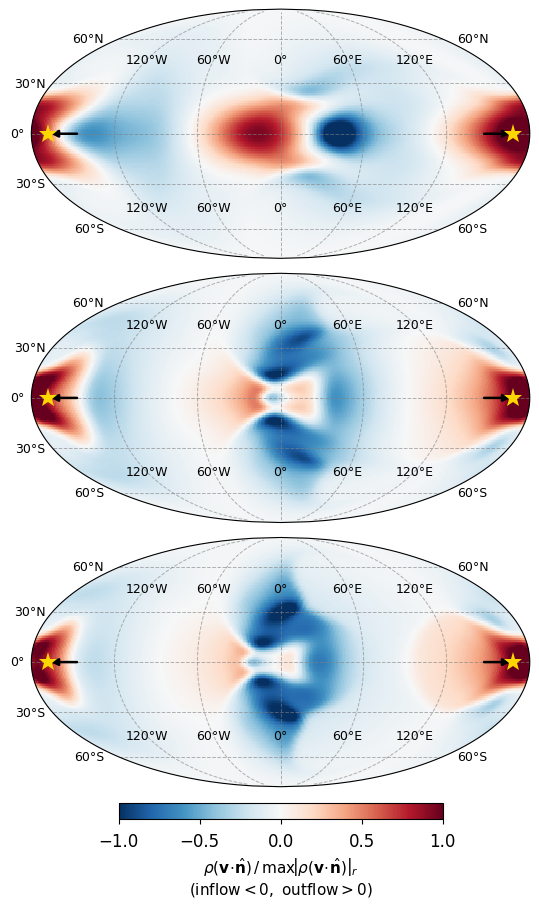

In [ ]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter, median_filter
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import matplotlib.colors as colors
from matplotlib.ticker import FixedLocator

plt.style.use("seaborn-v0_8-paper")

# =========================
# CONFIGURATION
# =========================
PATH = "/home/alejo/fargo3d/outputs/pds70hr_fid2_rs"
SNAP = 50

RSPH_FRACS = [0.3, 0.5, 0.6]      # radios en fracciones de R_H
SUBDIVISIONS = 5                  # resolución de la esfera (geodesic)

# Suavizado (recomendado: moderado para no "inventar" estructura)
SIGMA_LON = 2.5
SIGMA_LAT = 1.5
USE_MEDIAN = True
MED_SIZE = (3, 3)

NLON = 360
NLAT = 180

# Escala compartida: percentil para evitar outliers dominando
PCTL_VMAX_SIGNED = 99.0
CMAP_SIGNED = "RdBu_r"

# Opción de NORMALIZACIÓN por radio (recomendado para comparar geometría)
NORMALIZE_EACH_RADIUS = True   # True => colorbar [-1,1] (geométrica), False => física (g cm^-2 s^-1)

# Anotación estrella / dirección
STAR_LON = 180.0
STAR_LAT = 0.0
STAR_LABEL = "To star"

# =========================
# Anotación de estrella y flecha (manejo del seam +-180)
# =========================
def add_star_arrow_pm180(ax,
                         lon_deg=STAR_LON, lat_deg=STAR_LAT,
                         label=STAR_LABEL,
                         dlon_inside=15.0,
                         dlon_tail=30.0,
                         tail_lat_offset=0.0,
                         draw_meridian=False):
    seam_lons = [lon_deg, lon_deg - 360.0]
    for k, Lseam in enumerate(seam_lons):
        if Lseam > 0:
            L_star = Lseam - dlon_inside
            L_tail = Lseam - dlon_tail
        else:
            L_star = Lseam + dlon_inside
            L_tail = Lseam + dlon_tail

        lat0 = lat_deg + tail_lat_offset

        ax.annotate(
            "",
            xy=(L_star, lat_deg),
            xytext=(L_tail, lat0),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            arrowprops=dict(arrowstyle="-|>", lw=1.8, color="k"),
            zorder=12
        )

        ax.plot(
            L_star, lat_deg,
            marker="*", markersize=14,
            markeredgecolor="k", markerfacecolor="gold",
            transform=ccrs.PlateCarree(),
            zorder=13,
            label=label if k == 0 else None
        )

        if draw_meridian:
            ax.plot(
                [Lseam, Lseam], [-90, 90],
                transform=ccrs.PlateCarree(),
                linewidth=1.2, linestyle="--", color="k", alpha=0.5,
                zorder=8
            )

# =========================
# Helpers: regrid + smooth
# =========================
lon_grid = np.linspace(-180.0, 180.0, NLON, endpoint=False)
lat_grid = np.linspace(-90.0,  90.0,  NLAT)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

def regrid_and_smooth(pts, vals):
    """
    pts: (N,2) lon,lat en grados
    vals: (N,) valores en los centros de triángulos
    """
    Z_lin  = griddata(pts, vals, (LON, LAT), method="linear", fill_value=np.nan)
    Z_near = griddata(pts, vals, (LON, LAT), method="nearest")
    Z = np.where(np.isfinite(Z_lin), Z_lin, Z_near)

    if USE_MEDIAN:
        Z = median_filter(Z, size=MED_SIZE, mode="nearest")

    # lat: reflect, lon: wrap (periodicidad)
    Zs = gaussian_filter(Z, sigma=(SIGMA_LAT, SIGMA_LON), mode=("reflect", "wrap"))
    return Zs

def mollweide_gridlabels(ax, show_bottom=True, show_left=True):
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.7,
        color="gray",
        alpha=0.6,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = show_bottom
    gl.left_labels = show_left

    gl.xlocator = FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = FixedLocator(np.arange(-90,  91, 30))
    gl.xformatter = cticker.LongitudeFormatter(degree_symbol="°", number_format=".0f")
    gl.yformatter = cticker.LatitudeFormatter(degree_symbol="°", number_format=".0f")
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}
    return gl

# =========================
# SIMULATION
# =========================
sim = fp.Simulation(output_dir=PATH)
sim.units("CGS")
sim.set_units(UL=34 * sim.AU, UM=0.76 * sim.MSUN)

p = sim.load_planets(snapshot=SNAP)[0]
xp, yp = p.pos.x, p.pos.y
rhill = p.hill_radius

# =========================
# Compute signed flux maps (sin métricas integradas)
# =========================
Z_signed_list = []
vmax_signed_list = []

for RSPH_FRAC in RSPH_FRACS:
    # Cargamos un volumen un poco mayor que la esfera para interpolar bien
    RCUT_FRAC = RSPH_FRAC + 0.1
    cut_sphere = (xp, yp, 0.0, RCUT_FRAC * rhill)

    data = sim.load_field(
        fields=["gasdens", "gasv"],
        snapshot=SNAP,
        cut=cut_sphere,
        interpolate=True
    )

    sphere = fp.Surface(
        type="sphere",
        center=(xp, yp, 0.0),
        radius=RSPH_FRAC * rhill,
        subdivisions=SUBDIVISIONS
    )

    xcs, ycs, zcs = sphere.centers[:, 0], sphere.centers[:, 1], sphere.centers[:, 2]

    # reflect=True por half-disk (asumiendo tu configuración previa)
    rhoc = data.evaluate(field="gasdens", time=SNAP, var1=xcs, var2=ycs, var3=zcs, reflect=True)
    velc = data.evaluate(field="gasv",    time=SNAP, var1=xcs, var2=ycs, var3=zcs, reflect=True)

    velc_arr = np.asarray(velc)
    if velc_arr.ndim == 2 and velc_arr.shape[0] == 3:
        velc_arr = velc_arr.T

    normals = np.asarray(sphere.normals)
    if normals.ndim == 2 and normals.shape[0] == 3:
        normals = normals.T

    vn = np.einsum("ij,ij->i", velc_arr, normals)

    # Flujo por unidad de área: rho * vn (en CGS)
    F = np.asarray(rhoc).ravel() * vn * sim.UM / (sim.UL**2 * sim.UT)  # g cm^-2 s^-1

    # -------------------------
    # lon/lat para mapear
    # -------------------------
    x = xcs - xp
    y = ycs - yp
    z = zcs
    r = np.sqrt(x**2 + y**2 + z**2)
    lat = np.degrees(np.arcsin(z / r))
    lon = np.degrees(np.arctan2(y, x))
    pts = np.column_stack([lon, lat])

    Z_signed = regrid_and_smooth(pts, F)

    # vmax por panel (si vas a normalizar por radio o si quieres percentil individual)
    vmax_signed = np.nanpercentile(np.abs(Z_signed), PCTL_VMAX_SIGNED)
    if not np.isfinite(vmax_signed) or vmax_signed == 0:
        vmax_signed = 1.0

    if NORMALIZE_EACH_RADIUS:
        Z_signed = Z_signed / vmax_signed  # normaliza por el percentil elegido (robusto a outliers)
        vmax_signed = 1.0

    Z_signed_list.append(Z_signed)
    vmax_signed_list.append(vmax_signed)

# =========================
# Scaling compartido (físico o normalizado)
# =========================
if NORMALIZE_EACH_RADIUS:
    vmax_shared = 1.0
else:
    vmax_shared = np.nanmax(vmax_signed_list)
    if not np.isfinite(vmax_shared) or vmax_shared == 0:
        vmax_shared = 1.0

norm_shared = colors.TwoSlopeNorm(vmin=-vmax_shared, vcenter=0.0, vmax=vmax_shared)

# =========================
# Figure: 3 rows + shared bottom colorbar
# =========================
fig, axs = plt.subplots(
    3, 1,
    figsize=(9, 10),
    subplot_kw=dict(projection=ccrs.Mollweide())
)


fig.subplots_adjust(left=0.06, right=0.98, top=0.97, bottom=0.16, hspace=0.06)

pm_last = None
for i, (ax, RSPH_FRAC, Z_signed) in enumerate(zip(axs, RSPH_FRACS, Z_signed_list)):
    pm_last = ax.pcolormesh(
        LON, LAT, Z_signed,
        transform=ccrs.PlateCarree(),
        cmap=CMAP_SIGNED,
        norm=norm_shared,
        shading="auto"
    )

    mollweide_gridlabels(ax, show_bottom=(i == len(axs) - 1), show_left=True)
    add_star_arrow_pm180(ax, dlon_inside=12.0, dlon_tail=35.0, draw_meridian=False)


# Colorbar compartido
cbar = fig.colorbar(
    pm_last,
    ax=axs,
    orientation="horizontal",
    location="bottom",
    pad=0.02,
    fraction=0.02,
    aspect=20
)

cbar.ax.xaxis.get_offset_text().set_visible(False)


# Set colorbar label depending on normalization choice
if NORMALIZE_EACH_RADIUS:
    cbar.set_label(
        r"$\rho(\mathbf{v}\!\cdot\!\hat{\mathbf{n}})\,/\,"
        r"\max\!\left|\rho(\mathbf{v}\!\cdot\!\hat{\mathbf{n}})\right|_r$"
        "\n"
        r"$(\mathrm{inflow}<0,\ \mathrm{outflow}>0)$",
        fontsize=11
    )
else:
    cbar.set_label(
        r"$\rho(\mathbf{v}\!\cdot\!\hat{\mathbf{n}})\ "
        r"[\mathrm{g\ cm^{-2}\ s^{-1}}]\ "
        r"(\mathrm{inflow}<0,\ \mathrm{outflow}>0)$",
        fontsize=12
    )

# Set tick label size
cbar.ax.tick_params(labelsize=12)

plt.show()


#  Accretion metrics (integration)

Integrate inflow and outflow across the tessellated sphere and convert to physical units.

In [4]:
# ============================================================
# SNIPPET: integrate inflow / outflow across the tessellated sphere
# Assumes you already computed:
#   rhoc : density at triangle centers
#   velc : velocity vectors at triangle centers  (shape ~ (3,N) or (N,3))
#   sphere.normals : outward unit normals per triangle
#   sphere.areas   : triangle areas (in code-length^2)
#   sim.UM, sim.UL, sim.UT set (CGS)
# ============================================================

# --- make velc shape (N,3) robustly ---
velc_arr = np.asarray(velc)
if velc_arr.shape[0] == 3 and velc_arr.ndim == 2:
    velc_arr = velc_arr.T  # (N,3)
elif velc_arr.shape[-1] != 3:
    raise ValueError(f"Unexpected velc shape: {velc_arr.shape}")

normals = np.asarray(sphere.normals).T  # expected (N,3) after transpose? be safe:
if normals.shape[-1] != 3:
    normals = np.asarray(sphere.normals)  # try (N,3)
if normals.shape[-1] != 3:
    raise ValueError(f"Unexpected normals shape: {normals.shape}")

areas = np.asarray(sphere.areas).ravel()  # (N,)

rho = np.asarray(rhoc).ravel()            # (N,)

# --- normal velocity component (code units) ---
vn = np.einsum("ij,ij->i", velc_arr, normals)  # (N,)

# --- mass flux per unit area (code -> CGS): g cm^-2 s^-1 ---
F_cgs = rho * vn * sim.UM / (sim.UL**2 * sim.UT)

# --- split into inflow/outflow magnitudes (both >= 0) ---
Fin_cgs  = np.maximum(-F_cgs, 0.0)  # inflow magnitude
Fout_cgs = np.maximum( F_cgs, 0.0)  # outflow magnitude

# --- convert triangle areas to cm^2 ---
A_cgs = areas * sim.UL**2  # because area in code is UL^2

# --- integrate (g/s) ---
Mdot_in_gs  = np.sum(Fin_cgs  * A_cgs)
Mdot_out_gs = np.sum(Fout_cgs * A_cgs)
Mdot_net_gs = Mdot_out_gs - Mdot_in_gs   # sign convention with outward normals
# equivalently: net across surface is ∑(F_cgs * A_cgs)

# --- convert to MJup/yr and Msun/yr ---
SEC_PER_YR = 365.25 * 24 * 3600.0
MJUP_G     = 1.898e30
MSUN_G     = 1.98847e33

Mdot_in_Mjupyr  = Mdot_in_gs  * SEC_PER_YR / MJUP_G
Mdot_out_Mjupyr = Mdot_out_gs * SEC_PER_YR / MJUP_G
Mdot_net_Mjupyr = Mdot_net_gs * SEC_PER_YR / MJUP_G

Mdot_in_Msunyr  = Mdot_in_gs  * SEC_PER_YR / MSUN_G
Mdot_out_Msunyr = Mdot_out_gs * SEC_PER_YR / MSUN_G
Mdot_net_Msunyr = Mdot_net_gs * SEC_PER_YR / MSUN_G

print(f"Mdot_in  = {Mdot_in_gs:.3e} g/s  = {Mdot_in_Mjupyr:.3e} MJup/yr  = {Mdot_in_Msunyr:.3e} Msun/yr")
print(f"Mdot_out = {Mdot_out_gs:.3e} g/s  = {Mdot_out_Mjupyr:.3e} MJup/yr  = {Mdot_out_Msunyr:.3e} Msun/yr")
print(f"Mdot_net = {Mdot_net_gs:.3e} g/s  = {Mdot_net_Mjupyr:.3e} MJup/yr  = {Mdot_net_Msunyr:.3e} Msun/yr")

# Optional sanity checks:
# - Fraction of surface with inflow/outflow
frac_in  = np.mean(F_cgs < 0)
frac_out = np.mean(F_cgs > 0)
print(f"Surface fractions: inflow={frac_in:.3f}, outflow={frac_out:.3f}")


Mdot_in  = 1.445e+17 g/s  = 2.403e-06 MJup/yr  = 2.294e-09 Msun/yr
Mdot_out = 5.796e+16 g/s  = 9.637e-07 MJup/yr  = 9.198e-10 Msun/yr
Mdot_net = -8.656e+16 g/s  = -1.439e-06 MJup/yr  = -1.374e-09 Msun/yr
Surface fractions: inflow=0.791, outflow=0.209


## **Emision (Optional**)

#  3D emission surface with Plotly

Render a 3D spherical surface colored by flux using Plotly for interactive inspection.

In [ ]:
import plotly.graph_objects as go

# =========================
# 3D sphere map with Plotly (Surface on lon/lat grid)
# =========================

# Radio de la esfera (en unidades de simulación), consistente con tu Surface
R = RSPH_FRAC * rhill

# Convertir lon/lat (deg) -> (x,y,z) sobre esfera
lonr = np.radians(LON)
latr = np.radians(LAT)

Xs = R * np.cos(latr) * np.cos(lonr)
Ys = R * np.cos(latr) * np.sin(lonr)
Zs = R * np.sin(latr)

# El campo a pintar (elige uno)
C = Z_signed          # signed flux en la grilla regular
# C = Z_in            # inflow magnitude
# C = Z_out           # outflow magnitude

# (Opcional) límites simétricos para diverging
cmax = np.nanpercentile(np.abs(C), 99.0)
cmin, cmax = -cmax, cmax

fig = go.Figure()

fig.add_trace(go.Surface(
    x=Xs, y=Ys, z=Zs,
    surfacecolor=C,
    colorscale="RdBu",
    cmin=cmin, cmax=cmax,
    showscale=True,
    colorbar=dict(title="Flux [g cm^-2 s^-1]"),
    lighting=dict(ambient=0.6, diffuse=0.8, specular=0.2, roughness=0.9),
))

# =========================
# Marcar la "estrella" en 90°W (lon=-90, lat=0)
# =========================
STAR_LON = 180
STAR_LAT = 0.0

slon = np.radians(STAR_LON)
slat = np.radians(STAR_LAT)
xs = R * np.cos(slat) * np.cos(slon)
ys = R * np.cos(slat) * np.sin(slon)
zs = R * np.sin(slat)

fig.add_trace(go.Scatter3d(
    x=[xs], y=[ys], z=[zs],
    mode="markers+text",
    marker=dict(size=6, color="gold", line=dict(color="black", width=2)),
    text=["Star (90°W)"],
    textposition="top center"
))

fig.update_layout(
    title=f"3D spherical map of signed flux — snapshot {SNAP}",
    scene=dict(
        xaxis=dict(visible=True),
        yaxis=dict(visible=True),
        zaxis=dict(visible=True),
        aspectmode="data"
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()


#  Envelope emission and spectrum

Compute optically-thin grey luminosity and L_nu spectrum for the planetary envelope.

In [ ]:
import fargopy as fp
import numpy as np
import matplotlib.pyplot as plt

PATH = '/home/alejo/fargo3d/outputs/pds70hr_fid2_rs'
SNAP = 200
RES  = 720


# ============================================================
# LOAD SIMULATION / UNITS
# ============================================================
sim = fp.Simulation(output_dir=PATH)
sim.units('CGS')
sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)


# ============================================================
# CONFIG
# ============================================================
SNAP = 200
RES  = 80

# Envelope in Hill radii (within CUT_SPHERE = RH)
RMIN_RH = 0.05
RMAX_RH = 0.50

# Shock / compression selection inside envelope
USE_SHOCK_MASK = True
COMP_PERC      = 95
USE_MN_MASK    = True
MN_MIN         = 1.0

# Temperature proxy
USE_SHOCK_HEATING = True   # False -> use isothermal T everywhere
gamma = 1.4
mu    = 2.34

# Sound speed from disk aspect ratio h/r at r~1 UL (or set cs_cgs directly)
h_over_r = 0.072          # <-- set to your simulation value
cs_cgs   = None            # cm/s (override if known)

# Gas-only constant grey opacity (frequency-independent)
KAPPA_CGS_LIST = [1e-4, 1e-3, 1e-2]   # cm^2/g

# Spectrum grid (Hz)
NU_MIN = 1e11
NU_MAX = 3e14
N_NU   = 250

# Plot
OUTFIG = f"media/Lnu_env_snap{SNAP}.png"

# ============================================================
# CONSTANTS (CGS)
# ============================================================
G_CGS    = 6.67430e-8        # cm^3 g^-1 s^-2
MSUN_CGS = 1.98847e33        # g
kB_CGS   = 1.380649e-16      # erg/K
mH_CGS   = 1.6735575e-24     # g
h_CGS    = 6.62607015e-27    # erg*s
c_CGS    = 2.99792458e10     # cm/s
sigmaSB_CGS = 5.670374419e-5 # erg cm^-2 s^-1 K^-4

# ============================================================
# Helper: Planck B_nu in CGS (erg s^-1 cm^-2 Hz^-1 sr^-1)
# ============================================================
def Bnu_cgs(nu_hz, T_K):
    """
    nu_hz: array (Nnu,)
    T_K: array (Ncell,) or scalar
    returns: array (Nnu, Ncell) via broadcasting
    """
    nu = np.asarray(nu_hz, dtype=np.float64)[:, None]     # (Nnu,1)
    T  = np.asarray(T_K,  dtype=np.float64)[None, :]      # (1,Ncell)

    x = (h_CGS * nu) / (kB_CGS * np.maximum(T, 1e-300))
    # avoid overflow in exp for large x
    x = np.clip(x, 1e-12, 700.0)

    pref = (2.0 * h_CGS * nu**3) / (c_CGS**2)
    return pref / (np.expm1(x))  # exp(x)-1 stable

# ============================================================
# LOAD SIMULATION (assumes `sim` already exists and is in CGS)
# ============================================================
# Example:
# PATH = '/home/alejo/fargo3d/outputs/pds70hr_fid3_rs'
# sim = fp.Simulation(output_dir=PATH)
# sim.units('CGS')
# sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

p = sim.load_planets(snapshot = SNAP)[0]
xp, yp, zp = p.pos.x, p.pos.y, p.pos.z
RH = p.hill_radius

CUT_SPHERE = (xp, yp, zp, RH)

data = sim.load_field(['gasdens', 'gasv'], cut=CUT_SPHERE, snapshot = SNAP, interpolate=True)

xmin, xmax = data.var1_mesh[0].min(), data.var1_mesh[0].max()
ymin, ymax = data.var2_mesh[0].min(), data.var2_mesh[0].max()
zmin, zmax = data.var3_mesh[0].min(), data.var3_mesh[0].max()

xs = np.linspace(xmin, xmax, RES)
ys = np.linspace(ymin, ymax, RES)
zs = np.linspace(-zmax, zmax, RES)
X, Y, Z = np.meshgrid(xs, ys, zs, indexing='ij')  # (RES,RES,RES)

rho_code = data.evaluate(
    field='gasdens',
    var1=X, var2=Y, var3=Z,
    time = SNAP,
    reflect = True,
    interpolator='griddata',
    method='linear'
)
vel_code = data.evaluate(
    field='gasv',
    var1=X, var2=Y, var3=Z,
    time = SNAP,
    reflect = True,
    interpolator='griddata',
    method='linear'
)

# ============================================================
# UNITS (CGS)
# ============================================================
rho_cgs = rho_code * sim.URHO                     # g/cm^3
Vx = vel_code[0] * (sim.UL / sim.UT)              # cm/s
Vy = vel_code[1] * (sim.UL / sim.UT)              # cm/s
Vz = vel_code[2] * (sim.UL / sim.UT)              # cm/s

dx_cm = (xs[1] - xs[0]) * sim.UL
dy_cm = (ys[1] - ys[0]) * sim.UL
dz_cm = (zs[1] - zs[0]) * sim.UL
dV_cm3 = dx_cm * dy_cm * dz_cm

# ============================================================
# ENVELOPE MASK
# ============================================================
rp = np.sqrt((X - xp)**2 + (Y - yp)**2 + (Z - zp)**2)  # code units
env_mask = (rp >= RMIN_RH*RH) & (rp <= RMAX_RH*RH) & np.isfinite(rho_cgs) & (rho_cgs > 0)

# ============================================================
# DIV v (Cartesian on regular cut grid) [1/s]
# ============================================================
dVx_dx = np.gradient(Vx, dx_cm, axis=0)
dVy_dy = np.gradient(Vy, dy_cm, axis=1)
dVz_dz = np.gradient(Vz, dz_cm, axis=2)
div_v = dVx_dx + dVy_dy + dVz_dz
comp  = np.maximum(0.0, -div_v)

# ============================================================
# SOUND SPEED + BASE TEMPERATURE (isothermal)
# ============================================================
r0_cm = 1.0 * sim.UL
Mstar_cgs = 0.76 * MSUN_CGS
OmegaK = np.sqrt(G_CGS * Mstar_cgs / (r0_cm**3))

if cs_cgs is None:
    cs = h_over_r * r0_cm * OmegaK  # cm/s
else:
    cs = float(cs_cgs)

T1 = (mu * mH_CGS / kB_CGS) * cs**2  # K

# ============================================================
# NORMAL MACH (proxy) from grad(rho)
# ============================================================
drho_dx = np.gradient(rho_cgs, dx_cm, axis=0)
drho_dy = np.gradient(rho_cgs, dy_cm, axis=1)
drho_dz = np.gradient(rho_cgs, dz_cm, axis=2)

gnorm = np.sqrt(drho_dx**2 + drho_dy**2 + drho_dz**2) + 1e-99
nx = drho_dx / gnorm
ny = drho_dy / gnorm
nz = drho_dz / gnorm

vn = Vx*nx + Vy*ny + Vz*nz
Mn = np.abs(vn) / cs

# ============================================================
# TEMPERATURE FIELD (proxy)
# ============================================================
if USE_SHOCK_HEATING:
    M1 = np.maximum(Mn, 1.0)
    p2_p1 = 1.0 + (2.0*gamma/(gamma+1.0))*(M1**2 - 1.0)
    rho2_rho1 = ((gamma+1.0)*M1**2) / ((gamma-1.0)*M1**2 + 2.0)
    T2 = T1 * (p2_p1 / rho2_rho1)
    T = np.where(env_mask, T2, np.nan)
else:
    T = np.where(env_mask, T1, np.nan)

# ============================================================
# FINAL MASK
# ============================================================
mask = env_mask.copy()

if USE_SHOCK_MASK:
    comp_env = comp[env_mask]
    thr_comp = np.nanpercentile(comp_env, COMP_PERC) if comp_env.size else np.nan
    mask &= (comp >= thr_comp)
else:
    thr_comp = np.nan

if USE_MN_MASK:
    mask &= (Mn >= MN_MIN)

mask &= np.isfinite(T) & np.isfinite(rho_cgs) & (rho_cgs > 0)

# ============================================================
# BOLOMETRIC L (optically thin grey)
# ============================================================
def luminosity_bolometric(kappa_cgs):
    eps = np.where(mask, 4.0 * kappa_cgs * rho_cgs * sigmaSB_CGS * (T**4), 0.0)  # erg cm^-3 s^-1
    return np.sum(eps) * dV_cm3

# Emission-weighted characteristic temperature (for BB-equivalent reference)
w = np.where(mask, rho_cgs * (T**4), 0.0)
w_sum = np.sum(w) * dV_cm3
Tchar = (np.sum(np.where(mask, rho_cgs * (T**5), 0.0)) * dV_cm3) / np.maximum(w_sum, 1e-99)

# ============================================================
# SPECTRUM L_nu (optically thin grey, kappa frequency-independent)
# L_nu = ∫ 4π κ ρ B_ν(T) dV
# ============================================================
nu = np.logspace(np.log10(NU_MIN), np.log10(NU_MAX), N_NU)

# Flatten only masked cells to keep it fast
rho_m = rho_cgs[mask].ravel()
T_m   = T[mask].ravel()

if rho_m.size == 0:
    raise RuntimeError("Mask is empty: adjust RMIN_RH/RMAX_RH, COMP_PERC, or MN_MIN.")

B = Bnu_cgs(nu, T_m)  # (Nnu, Ncell)

# Precompute the common factor per kappa
common = 4.0 * np.pi * dV_cm3  # sr * volume element factor

Lnu_dict = {}
for kappa in KAPPA_CGS_LIST:
    # (Nnu,) = common * kappa * sum_i rho_i * Bnu(nu,Ti)
    Lnu = common * kappa * np.sum(rho_m[None, :] * B, axis=1)  # erg/s/Hz
    Lnu_dict[kappa] = Lnu

# Peak (for a chosen kappa, e.g. middle one)
kappa_ref = KAPPA_CGS_LIST[len(KAPPA_CGS_LIST)//2]
Lnu_ref = Lnu_dict[kappa_ref]
ipeak = np.argmax(Lnu_ref)
nu_peak = nu[ipeak]
lam_peak_um = (c_CGS / nu_peak) * 1e4  # cm -> micron

# --- Consistency check: integrate Lnu over nu and compare to Lbol
for kappa in KAPPA_CGS_LIST:
    Lbol_from_Lnu = np.trapz(Lnu_dict[kappa], nu)  # erg/s
    Lbol_direct   = luminosity_bolometric(kappa)  # erg/s
    rel_err = (Lbol_from_Lnu - Lbol_direct) / Lbol_direct
    print(f"[check] kappa={kappa:.1e}: Lbol(trapz Lnu)={Lbol_from_Lnu:.3e}, "
          f"Lbol(direct)={Lbol_direct:.3e}, rel_err={rel_err:.3e}")

# ============================================================
# PRINT SUMMARY
# ============================================================
print("=== Units (CGS) ===")
print(f"sim.URHO = {sim.URHO:.3e} g/cm^3 per code-rho")
print(f"sim.UL   = {sim.UL:.3e} cm")
print(f"sim.UT   = {sim.UT:.3e} s\n")

print("=== Envelope / mask stats ===")
print(f"cs = {cs:.3e} cm/s,  T1 = {T1:.2f} K")
if np.isfinite(thr_comp):
    print(f"Compression threshold ({COMP_PERC}th perc in env) = {thr_comp:.3e} 1/s")
print(f"Cells in envelope: {env_mask.sum()} / {env_mask.size}")
print(f"Cells in final mask: {mask.sum()} / {mask.size}")
print(f"Tchar (emission-weighted) = {Tchar:.2f} K\n")

print("=== Bolometric luminosity band (optically thin grey) ===")
for kappa in KAPPA_CGS_LIST:
    Lbol = luminosity_bolometric(kappa)
    print(f"kappa={kappa:.1e} cm^2/g -> Lbol = {Lbol:.3e} erg/s")

print("\n=== Spectral peak (for kappa_ref) ===")
print(f"kappa_ref = {kappa_ref:.1e} cm^2/g")
print(f"nu_peak (max of Lnu) = {nu_peak:.3e} Hz")
print(f"lambda_peak = {lam_peak_um:.2f} micron")

# ============================================================
# PLOT Lnu
# ============================================================
plt.close("all")
fig, ax = plt.subplots(figsize=(7.2, 5.2))

for kappa in KAPPA_CGS_LIST:
    ax.loglog(nu, Lnu_dict[kappa], label=rf'$\kappa={kappa:.0e}\ \mathrm{{cm^2\,g^{{-1}}}}$')

ax.axvline(nu_peak, linestyle="--", linewidth=1.0)
ax.set_xlabel(r'$\nu\ \mathrm{[Hz]}$')
ax.set_ylabel(r'$L_\nu\ \mathrm{[erg\,s^{-1}\,Hz^{-1}]}$')
ax.set_title(r'Envelope emission (optically thin grey): $L_\nu=\int 4\pi\kappa\rho B_\nu(T)\,dV$')
ax.legend(frameon=False)

# Secondary x-axis in wavelength (micron)
ax2 = ax.twiny()
ax2.set_xscale("log")
# Match limits: lambda = c/nu
nu_lo, nu_hi = ax.get_xlim()
lam_hi_um = (c_CGS / nu_lo) * 1e4
lam_lo_um = (c_CGS / nu_hi) * 1e4
ax2.set_xlim(lam_hi_um, lam_lo_um)
ax2.set_xlabel(r'$\lambda\ \mathrm{[\mu m]}$')

plt.tight_layout()
#plt.savefig(OUTFIG, dpi=250)
plt.show()

#  Emission calculation in cut sphere

Load cut-sphere fields, compute temperature proxy, mask regions, and estimate luminosity.

In [ ]:
import fargopy as fp
import numpy as np

# ============================================================
# CONFIG
# ============================================================
SNAP = 200
RES  = 80

# Envelope radii in Hill radii (within the CUT_SPHERE = RH)
RMIN_RH = 0.05
RMAX_RH = 0.50

# Shock / compression selection inside the envelope
USE_SHOCK_MASK   = True
COMP_PERC        = 95      # percentile threshold in envelope
USE_MN_MASK      = True
MN_MIN           = 1.0

# Temperature proxy
USE_SHOCK_HEATING = True   # False -> T = T_iso everywhere
gamma = 1.4
mu    = 2.34

# Set sound speed using disk aspect ratio h/r at r~1 (code length unit)
h_over_r = 0.072          # <-- set to your simulation value
cs_cgs   = None            # if you know cs directly in cm/s, set it here and ignore h_over_r

# Gas-only grey opacity (constant band; DO NOT use Kramers at ~40 K)
KAPPA_CGS_LIST = [1e-4, 1e-3, 1e-2]  # cm^2/g

# ============================================================
# CONSTANTS
# ============================================================
G_CGS    = 6.67430e-8            # cm^3 g^-1 s^-2
MSUN_CGS = 1.98847e33            # g
kB_CGS   = 1.380649e-16          # erg/K
mH_CGS   = 1.6735575e-24         # g
h_SI     = 6.62607015e-34        # J s  (for nu_peak; convert T->SI via kB_SI later)
kB_SI    = 1.380649e-23          # J/K

sigmaSB_CGS = 5.670374419e-5     # erg cm^-2 s^-1 K^-4

# ============================================================
# LOAD SIMULATION (assumes `sim` already exists and is in CGS)
# ============================================================
# sim = fp.Simulation(output_dir=PATH)
# sim.units('CGS')
# sim.set_units(UL=34*sim.AU, UM=0.76*sim.MSUN)

# Planet
p = sim.load_planets(snapshot = SNAP)[0]
xp, yp, zp = p.pos.x, p.pos.y, p.pos.z
RH = p.hill_radius

# Cut sphere around planet (radius = RH, in code length units)
CUT_SPHERE = (xp, yp, zp, RH)

# Load density and velocity within the cut
data = sim.load_field(['gasdens', 'gasv'], cut=CUT_SPHERE, snapshot = SNAP, interpolate=True)

# Build regular grid for interpolation (in code-length units)
xmin, xmax = data.var1_mesh[0].min(), data.var1_mesh[0].max()
ymin, ymax = data.var2_mesh[0].min(), data.var2_mesh[0].max()
zmin, zmax = data.var3_mesh[0].min(), data.var3_mesh[0].max()

xs = np.linspace(xmin, xmax, RES)
ys = np.linspace(ymin, ymax, RES)
zs = np.linspace(zmin, zmax, RES)

# indexing='ij' for consistent axes: axis0=x, axis1=y, axis2=z
X, Y, Z = np.meshgrid(xs, ys, zs, indexing='ij')

# Interpolated density (dimensionless field values; convert using sim.URHO)
rho = data.evaluate(
    field='gasdens',
    var1=X, var2=Y, var3=Z,
    time = SNAP,
    interpolator='griddata',
    method='nearest'
)
# rho shape: (RES,RES,RES)

# Interpolated velocity (dimensionless; convert using sim.UL/sim.UT)
vel = data.evaluate(
    field='gasv',
    var1=X, var2=Y, var3=Z,
    time = SNAP,
    interpolator='griddata',
    method='nearest'
)
# vel shape: (3,RES,RES,RES)

# ============================================================
# UNIT CONVERSIONS (CGS-consistent)
# ============================================================
# Density in CGS: g/cm^3
rho_cgs = rho * sim.URHO

# Velocity in CGS: cm/s
Vx = vel[0] * (sim.UL / sim.UT)
Vy = vel[1] * (sim.UL / sim.UT)
Vz = vel[2] * (sim.UL / sim.UT)

# Grid spacing in code units
dx_code = xs[1] - xs[0]
dy_code = ys[1] - ys[0]
dz_code = zs[1] - zs[0]

# Spacing in CGS (cm)
dx_cm = dx_code * sim.UL
dy_cm = dy_code * sim.UL
dz_cm = dz_code * sim.UL

# ============================================================
# GEOMETRY: envelope inside [RMIN_RH, RMAX_RH]
# All radii here are in code length units; RH is also in code units.
# ============================================================
rp = np.sqrt((X - xp)**2 + (Y - yp)**2 + (Z - zp)**2)  # code units
env_mask = (rp >= RMIN_RH*RH) & (rp <= RMAX_RH*RH) & np.isfinite(rho_cgs) & (rho_cgs > 0)

# ============================================================
# DIVERGENCE (Cartesian on the regular cut grid) in CGS: 1/s
# ============================================================
dVx_dx = np.gradient(Vx, dx_cm, axis=0)
dVy_dy = np.gradient(Vy, dy_cm, axis=1)
dVz_dz = np.gradient(Vz, dz_cm, axis=2)
div_v  = dVx_dx + dVy_dy + dVz_dz
comp   = np.maximum(0.0, -div_v)  # 1/s

# ============================================================
# SOUND SPEED AND BASE ISOTHERMAL TEMPERATURE (CGS)
# ============================================================
# Use r0 = 1 UL as reference orbital radius (in cm) to compute OmegaK
r0_cm = 1.0 * sim.UL
Mstar_cgs = 0.76 * MSUN_CGS
OmegaK = np.sqrt(G_CGS * Mstar_cgs / (r0_cm**3))  # 1/s

if cs_cgs is None:
    cs = h_over_r * r0_cm * OmegaK  # cm/s
else:
    cs = float(cs_cgs)

# Isothermal background temperature (K): cs^2 = kB T / (mu mH)
T1 = (mu * mH_CGS / kB_CGS) * cs**2

# ============================================================
# SHOCK NORMAL ~ grad(rho) AND NORMAL MACH
# ============================================================
# Gradients for direction; rho_cgs used but units irrelevant for direction
drho_dx = np.gradient(rho_cgs, dx_cm, axis=0)
drho_dy = np.gradient(rho_cgs, dy_cm, axis=1)
drho_dz = np.gradient(rho_cgs, dz_cm, axis=2)

gnorm = np.sqrt(drho_dx**2 + drho_dy**2 + drho_dz**2) + 1e-99
nx = drho_dx / gnorm
ny = drho_dy / gnorm
nz = drho_dz / gnorm

vn = Vx*nx + Vy*ny + Vz*nz  # cm/s
Mn = np.abs(vn) / cs

# ============================================================
# TEMPERATURE FIELD (proxy)
# ============================================================
if USE_SHOCK_HEATING:
    M1 = np.maximum(Mn, 1.0)
    p2_p1 = 1.0 + (2.0*gamma/(gamma+1.0))*(M1**2 - 1.0)
    rho2_rho1 = ((gamma+1.0)*M1**2) / ((gamma-1.0)*M1**2 + 2.0)
    T2 = T1 * (p2_p1 / rho2_rho1)
    T = np.where(env_mask, T2, np.nan)
else:
    T = np.where(env_mask, T1, np.nan)

# ============================================================
# FINAL MASK (envelope + compression percentile + Mn threshold)
# ============================================================
mask = env_mask.copy()

if USE_SHOCK_MASK:
    comp_env = comp[env_mask]
    thr_comp = np.nanpercentile(comp_env, COMP_PERC) if comp_env.size else np.nan
    mask &= (comp >= thr_comp)
else:
    thr_comp = np.nan

if USE_MN_MASK:
    mask &= (Mn >= MN_MIN)

mask &= np.isfinite(T) & np.isfinite(rho_cgs) & (rho_cgs > 0)

# ============================================================
# VOLUME ELEMENT ON REGULAR GRID (cm^3)
# ============================================================
dV_cm3 = dx_cm * dy_cm * dz_cm

# ============================================================
# LUMINOSITY (OPTICALLY THIN GREY) AND CHARACTERISTIC FREQUENCY
# L = ∫ 4 κ ρ σ T^4 dV     (erg/s)
# ============================================================
# Emission weighting (for T_char)
w = np.where(mask, rho_cgs * (T**4), 0.0)
w_sum = np.sum(w) * dV_cm3
Tchar = (np.sum(np.where(mask, rho_cgs * (T**5), 0.0)) * dV_cm3) / np.maximum(w_sum, 1e-99)

# "BB-equivalent" peak frequency (reference only)
# ν_peak ≈ 2.821439 kB T / h  (use SI constants)
nu_peak = 2.821439 * kB_SI * Tchar / h_SI  # Hz
lam_peak_um = 2898.0 / np.maximum(Tchar, 1e-99)  # µm

print("=== Units (CGS) ===")
print(f"sim.URHO = {sim.URHO:.3e} g/cm^3 per code-rho")
print(f"sim.UL   = {sim.UL:.3e} cm")
print(f"sim.UT   = {sim.UT:.3e} s")
print("")
print("=== Envelope / mask stats ===")
print(f"cs = {cs:.3e} cm/s,  T1 = {T1:.2f} K")
if np.isfinite(thr_comp):
    print(f"Compression threshold ({COMP_PERC}th perc in env) = {thr_comp:.3e} 1/s")
print(f"Cells in envelope: {env_mask.sum()} / {env_mask.size}")
print(f"Cells in final mask: {mask.sum()} / {mask.size}")
print(f"Tchar (emission-weighted) = {Tchar:.2f} K")
print(f"lambda_peak ~ {lam_peak_um:.2f} micron (BB-equivalent reference)")
print(f"nu_peak ~ {nu_peak:.3e} Hz (BB-equivalent reference)")

print("\n=== Luminosity band (optically thin grey; gas-only constant kappa) ===")
for kappa_cgs in KAPPA_CGS_LIST:
    # emissivity per volume: 4 κ ρ σ T^4  [erg cm^-3 s^-1]
    eps = np.where(mask, 4.0 * kappa_cgs * rho_cgs * sigmaSB_CGS * (T**4), 0.0)
    L_erg_s = np.sum(eps) * dV_cm3
    print(f"kappa={kappa_cgs:.1e} cm^2/g  ->  L = {L_erg_s:.3e} erg/s")

# ============================================================
# OPTIONAL: local optical depth sanity check tau ~ kappa rho ell
# ============================================================
ELL_cm = 0.1 * RH * sim.UL
rho_med = np.nanmedian(np.where(mask, rho_cgs, np.nan))
T_med   = np.nanmedian(np.where(mask, T, np.nan))
print("\n=== Local tau sanity check (tau ~ kappa rho ell) ===")
print(f"rho_med(mask) = {rho_med:.3e} g/cm^3,  T_med(mask) = {T_med:.2f} K,  ell = {ELL_cm:.2e} cm")
for kappa_cgs in KAPPA_CGS_LIST:
    tau_loc = kappa_cgs * rho_med * ELL_cm
    print(f"kappa={kappa_cgs:.1e} -> tau_loc ~ {tau_loc:.3e}")
